# 📘 원리(Concepts)

## 1) 핵심 지표

* **MA**: 단기/중기 이동평균. 기본 `(MA20, MA60)`.
* **OBV**: On-Balance Volume. 수급(매집/분산) 흐름을 누적.
* **ATR%**: 변동성(14기간 ATR / 종가). 리스크 스케일로 사용.
* **RS**: Relative Strength. 동일 주기 수익률에서 “종목 − 벤치마크”.

## 2) 기술 진입 점수(EntryScore)

* 4개의 이진 신호 합(0~4):

  * **Trend_OK**: 가격>MA1, MA1>MA2
  * **OBV_pos**: 최근 OBV 기울기(+)
  * **RS_pos**: 최근 누적 RS > 0
  * **ATR_calm**: ATR%가 최근 저점대 근처(저변동)
* 기술 매수 기본: `EntryScore ≥ 4 → BUY_sig=1`
* 기술 매도 기본: 과열/하락 배열/다이버전스 등의 조합 → `SELL_sig=1`

## 3) 이벤트 기반 신호

* **E_exo**: 외생 이벤트(금리/전쟁/정책 등)의 강도
* **E_endo**: 내생 이벤트(실적, 수주, 신제품 등)의 강도
* **E_event = α·E_endo + β·E_exo**
* **RiskOn/RiskOff**:

  * `E_exo ≥ θ_on → RiskOn=1`
  * `E_exo ≤ θ_off → RiskOff=1`
* **S_entry = EntryScore + γ·E_event**
* 이벤트 매수: `BUY_sig2 = (RiskOn==1) & (S_entry ≥ τ_buy)`
* 이벤트 매도: `SELL_sig2 = SELL_sig or RiskOff`

## 4) 포지션 강도(비중) — 실무적 원칙

* **Volatility Targeting**: 변동성↑ → 비중↓, 변동성↓ → 비중↑
  `w_vol = risk_scale · (SignalStrength / max(ATR%, atr_floor))`
* **신호 강도 스코어(0~1)**

  * `S_tech = EntryScore / 4`
  * `S_evt = sigmoid(λ·E_event)`
  * `S = w_t·S_tech + w_e·S_evt` (RiskOn=0이면 패널티 곱 가능)
* **(선택) 부분 켈리 혼합**: 추정 μ/σ² 기반 비중을 소량(예 30%) 혼합
* 안전장치: `w_max` 상한, 음수 비중 금지(롱온리), `atr_floor` 사용.

## 5) 시계열/구간/가시화

* `basis`: `"D"`, `"W-FRI"`, `"2W-FRI"`, `"M"` 등 리샘플 기준.
* `start_date`, `end_date`, `warmup_days`로 분석 구간과 초기 안정화 제어.
* 메인 플롯: Close+MA, (옵션) ATR%/정규화 OBV를 **우측축** 오버레이.
* 이벤트 라벨: 필터(`topk/quantile/threshold`)와 기간 집계를 통해 과밀 표시 억제.

---



# 🛠️ 함수/사용 가이드

> 아래를 그대로 두 개의 마크다운 셀로 복붙해서 사용하면 된다.
> (셀1=원리, 셀2=함수/가이드)

## A. 주요 함수 목록

### 1) `plot_strategy_with_events(...) → mix: DataFrame`

단일 종목의 가격/지표/이벤트/신호를 그려주고, 계산된 테이블(열 다수 포함)을 반환.

**핵심 파라미터**

* `symbol: str` — 티커(한국 6자리/미국/홍콩 등).
* `name: Optional[str]` — 종목명. **생략 시 `get_display_name()`로 자동 채움**.
* `basis: str` — 리샘플 기준 (`"D"`, `"W-FRI"`, `"2W-FRI"`, `"M"`).
* `ma_windows: (int,int)` — MA 단/중기 윈도(기본 20/60).
* `rs_index_code: Optional[str]` — RS 벤치마크. **생략 시 `auto_benchmark()`로 자동**.
* `events_df: Optional[pd.DataFrame]` — 이벤트 표(외생/내생 통합). 기간 내로 자동 슬라이스.
* `params: EventRuleParams` — 이벤트 임계치(θ_on/off), γ, α/β, τ_buy 등.
* `signal_type: "event"|"tech"` — 차트에 표시할 신호 세트 선택(계산은 둘 다 포함).
* `event_filter_mode: "topk"|"quantile"|"threshold"` + `event_top_k|event_q|event_min_strength` — 라벨 필터 강도.
* `start_date, end_date` — 분석 구간(워밍업은 `warmup_days`로 앞부분 더 로드 후 컷).
* `show_obv, show_atr, show_rs: bool` — **보조패널(아래쪽 서브 차트)** on/off.
* `overlay_atr: Optional[bool]` / `overlay_obv: Optional[str]` — **메인 차트 오버레이**.

  * **None(기본)**이면 `show_*`를 그대로 따라감.
  * 직접 지정하면(`True`/`"zscore"` 등) **show_*와 무관하게** 오버라이드.
  * `overlay_obv`는 `"none"|"zscore"|"minmax"` 중 택1.

**반환 DataFrame 주요 열**

* 원시/지표: `Open, High, Low, Close, Volume, MA{m1}, MA{m2}, ATR%, OBV, RS`
* 기술 신호: `Trend_OK, OBV_pos, RS_pos, ATR_calm, EntryScore, BUY_sig, SELL_sig`
* 이벤트: `E_exo, E_endo, E_event, RiskOn, RiskOff, S_entry, BUY_sig2, SELL_sig2`
* (추가 사이징 적용 후) `S_tech_n, S_evt_n, S_total, w_target`

**예시**

```python
# 최소 실행(티커만): 이름/벤치마크 자동
mix = plot_strategy_with_events(
    "117670", basis="W-FRI",
    events_df=events, params=params, signal_type="event",
    start_date="2024-12-01", end_date="2025-10-01",
    warmup_days=120,
    # show_*만 조작하면 메인 오버레이도 같이 따라감(None 기본)
    show_obv=False, show_atr=False, show_rs=False
)
```

### 2) `auto_benchmark(symbol: str) -> str`

티커로 시장을 추론해 RS 벤치마크를 자동 선택.

* KOSPI→`KS11`, KOSDAQ/KONEX→`KQ11`, NASDAQ→`IXIC`, NYSE/AMEX→`SPY`,
  HKEX→`HSI`, SSE→`SSEC`, SZSE→`SZSC`(환경에 따라 대체), 실패 시 `SPY` 폴백.

### 3) `get_display_name(symbol: str) -> str`

티커의 **표시용 종목명** 자동 조회(KRX/NASDAQ/NYSE/AMEX/HKEX/SSE/SZSE). 실패 시 티커 그대로.

### 4) `add_position_weights(mix, SizingParams) → mix`

신호 강도(기술+이벤트)와 변동성 타기팅(+옵션 켈리)을 결합해 **비중 열**(`w_target`)을 추가.

```python
from dataclasses import dataclass

@dataclass
class SizingParams:
    w_t: float = 0.5      # 기술 가중
    w_e: float = 0.5      # 이벤트 가중
    lambda_evt: float = 1.0
    atr_floor: float = 0.01
    risk_scale: float = 1.0
    w_max: float = 1.0
    use_kelly: bool = False
    kelly_frac: float = 0.25
    kelly_lookback: int = 20
    kelly_mix: float = 0.0
    riskon_penalty: float = 1.0  # RiskOn=0일 때 곱할 감산

size_params = SizingParams(w_t=0.6, w_e=0.4, lambda_evt=1.2,
                           atr_floor=0.012, risk_scale=0.6, w_max=1.0,
                           use_kelly=True, kelly_frac=0.25, kelly_lookback=20, kelly_mix=0.3,
                           riskon_penalty=0.6)

mix = add_position_weights(mix, size_params)
```

### 5) 이벤트 로드/필터(예)

* `load_events_csv_exo(path)`, `load_events_csv_endo(path)` → 단일 스키마로 병합
* `aggregate_events_by_period(events_df, basis, signed=True)` → 기간 집계
* 플롯 필터는 `plot_strategy_with_events(..., event_filter_mode, event_top_k|event_q|event_min_strength)`로 제어.

### 6) 백테스트(요지)

* 기술만: `simulate_backtest_from_mix(mix, use_event_signals=False, ...)`
* 이벤트 결합: `simulate_backtest_from_mix(mix, use_event_signals=True, ...)`
* 포지션 크기: 기존 `strength/ATR%` 대신 `mix["w_target"]` 사용 권장.

```python
bt_res, bt_perf = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=True,
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True  # 내부에서 w_target 사용하도록 구현 권장
)
bt_perf
```

## B. 실전 튜닝 요령

* **신호 너무 적음**: `basis="D"` 또는 `"2W-FRI"`, `ma_windows` 단축(예 10/40), `τ_buy`↓, `θ_on`↓.
* **신호 너무 잦음/노이즈**: `ma_windows` 확대(20/60), `ATR_calm` 기준 유지, `τ_buy`↑, `θ_on`↑.
* **이벤트 과밀**: `event_filter_mode="topk", event_top_k=1~2` 또는 `quantile q=0.95~0.99`.
* **비중 과함**: `risk_scale↓`, `atr_floor↑`, `w_max↓`, 켈리 비중(`kelly_mix`) 최소화.
* **낙폭 크다**: `RiskOff` 민감도 상향(`θ_off` 덜 음수로), `atr_stop_mult` 사용(백테스트 내부).

## C. 빠른 사용 패턴

1. **이벤트+기술 결합, 기본 플롯(간결)**

```python
mix = plot_strategy_with_events("328130", basis="W-FRI",
                                events_df=events, params=params, signal_type="event",
                                start_date="2023-01-01", end_date="2025-10-01",
                                warmup_days=120,
                                show_obv=False, show_atr=False, show_rs=False)
mix = add_position_weights(mix, SizingParams(w_t=0.6, w_e=0.4, risk_scale=0.7))
```

2. **기술만, 세부 지표 함께 보기**

```python
mix = plot_strategy_with_events("NVDA", basis="W-FRI",
                                events_df=None, params=params, signal_type="tech",
                                start_date="2022-01-01",
                                show_obv=True, show_atr=True, show_rs=True)
```

3. **오버레이만 켜고 보조패널은 끄기(명시적 오버라이드)**

```python
mix = plot_strategy_with_events("117670", basis="W-FRI",
                                events_df=events, params=params, signal_type="event",
                                show_obv=False, show_atr=False,
                                overlay_obv="zscore", overlay_atr=True)
```

---

### 참고

* `assert_signal_policy`는 제거되어, **BUY 신호가 없어도 차트는 출력**된다.
* `name/rs_index_code` 생략 시 자동 추론(환경에 따라 일부 시장은 폴백).
* 중국/홍콩 티커는 문자열로 전달(선행 0 유지).


---
---
---

In [1]:
## 0) 환경 준비 / 패키지 설치
!pip -q install pandas numpy finance-datareader

In [2]:
## Library import

import math
from typing import Dict, Tuple, Optional

import io, sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import FinanceDataReader as fdr
from typing import List, Tuple, Dict, Optional, Union
from dataclasses import dataclass

In [3]:

# Colab 한글폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 설정 후 세션 재시작

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [4]:
import matplotlib.pyplot as plt


plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

import warnings
warnings.filterwarnings("ignore")

In [5]:

START_DATE = "2020-01-01"
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지 (폰트는 환경에 맞게 별도 설정)


# 공통 유틸 & 리샘플/지표(MA/ATR/OBV/RS)

In [6]:
def _parse_dt(x, fallback=None):
    if x is None:
        return pd.to_datetime(fallback) if fallback is not None else None
    return pd.to_datetime(x)


def ensure_dtindex(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'Date' in df.columns: df = df.set_index('Date')
        else: raise ValueError("No DatetimeIndex and no 'Date' column.")
    df.index = pd.to_datetime(df.index)
    return df.sort_index()

def resample_ohlcv(df: pd.DataFrame, basis: str="D") -> pd.DataFrame:
    # basis: "D" | "W-FRI" | "2W-FRI" | "M"
    df = ensure_dtindex(df)
    if basis == "D":
        return df[['Open','High','Low','Close','Volume']].dropna(how='any').copy()
    if basis in ["W-FRI","2W-FRI","M"]:
        o = df['Open'].resample(basis).first()
        h = df['High'].resample(basis).max()
        l = df['Low' ].resample(basis).min()
        c = df['Close'].resample(basis).last()
        v = df['Volume'].resample(basis).sum()
        out = pd.concat([o,h,l,c,v], axis=1)
        out.columns = ['Open','High','Low','Close','Volume']
        return out.dropna(how="any")
    raise ValueError("basis must be 'D','W-FRI','2W-FRI','M'")

def rolling_mean(s: pd.Series, w:int, minp:int=1) -> pd.Series:
    return s.rolling(w, min_periods=minp).mean()

def atr(df: pd.DataFrame, n:int=14, minp:int=1) -> pd.Series:
    h,l,c = df['High'], df['Low'], df['Close']
    pc = c.shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.rolling(n, min_periods=minp).mean()

def obv(df: pd.DataFrame) -> pd.Series:
    direction = np.sign(df['Close'].diff().fillna(0))
    return (direction * df['Volume']).cumsum()

def rel_strength(stock: pd.DataFrame, index_df: pd.DataFrame) -> pd.Series:
    s = stock['Close'].pct_change()
    i = index_df['Close'].pct_change()
    ref = pd.concat([s,i], axis=1, join='inner').dropna()
    return ref.iloc[:,0] - ref.iloc[:,1]

def guess_benchmark(symbol: str) -> str:
    # 간단 휴리스틱: 숫자 6자리면 KOSDAQ, 아니면 미국
    if symbol.isdigit() and len(symbol)==6: return "KQ11"
    return "SPY"

def compute_indicators(df_raw: pd.DataFrame,
                       basis: str="W-FRI",
                       ma_windows: Tuple[int,int]=(20,60),
                       atr_n:int=14,
                       rs_index_code: Optional[str]=None,
                       warmup: str="loose") -> pd.DataFrame:
    ohlc = resample_ohlcv(df_raw, basis)
    m1, m2 = ma_windows
    out = ohlc.copy()
    out[f"MA{m1}"] = rolling_mean(out['Close'], m1, minp=1)
    out[f"MA{m2}"] = rolling_mean(out['Close'], m2, minp=1)
    out["ATR"] = atr(out, atr_n, minp=1)
    out["ATR%"] = out["ATR"] / out["Close"]
    out["OBV"] = obv(out)

    bench_code = rs_index_code or guess_benchmark(str(df_raw.columns.name or ""))
    idx = fdr.DataReader(bench_code, start=str(out.index.min().date()))
    idx_r = resample_ohlcv(idx, basis)
    out["RS"] = rel_strength(out, idx_r).reindex(out.index)

    if warmup == "strict": return out.dropna()
    return out.dropna(subset=["Close"])


# 신호(체크리스트) 생성

In [7]:
def make_signals_from_tab(tab: pd.DataFrame, m1:int=20, m2:int=60) -> pd.DataFrame:
    t = tab.copy()
    t["OBV_slope10"] = t["OBV"].diff(10)
    t["RS_8_sum"] = t["RS"].rolling(8, min_periods=1).sum()
    t["ATRmin26"] = t["ATR%"].rolling(26, min_periods=1).min()

    t["ATR_calm"] = (t["ATR%"] <= t["ATRmin26"]*1.1).astype(int)
    t["Trend_OK"] = ((t["Close"] > t[f"MA{m1}"]) & (t[f"MA{m1}"] > t[f"MA{m2}"])).astype(int)
    t["OBV_pos"]  = (t["OBV_slope10"] > 0).astype(int)
    t["RS_pos"]   = (t["RS_8_sum"] > 0).astype(int)

    t["EntryScore"] = t["Trend_OK"] + t["OBV_pos"] + t["RS_pos"] + t["ATR_calm"]
    t["BUY_sig"]    = (t["EntryScore"] >= 4).astype(int)

    below_ma1 = (t["Close"] < t[f"MA{m1}"]).astype(int)
    t["BelowMA1_2bars"] = (below_ma1.rolling(2, min_periods=2).sum() == 2).astype(int)

    q80 = t["ATR%"].rolling(26, min_periods=10).quantile(0.8)
    t["ATR_hot"] = (t["ATR%"] > q80).astype(int)

    price_hh = t["Close"] > t["Close"].rolling(20, min_periods=1).max().shift(1)
    obv_hh   = t["OBV"]   > t["OBV"].rolling(20,   min_periods=1).max().shift(1)
    t["OBV_div_minus"] = ((price_hh) & (~obv_hh)).astype(int)

    t["SELL_sig"] = ((t["BelowMA1_2bars"]==1) | (t["OBV_div_minus"]==1) | (t["ATR_hot"]==1)).astype(int)
    return t


# 이벤트 CSV 로드 + 외생/내생 표시

In [8]:
def _map_direction_to_polarity(s: pd.Series) -> pd.Series:
    v = s.astype(str).str.lower().str.strip()
    v = v.map({"pos":"positive","neg":"negative"}).fillna(v)
    return (v.map({
        "positive":1.0,"bullish":1.0,"up":1.0,
        "negative":-1.0,"bearish":-1.0,"down":-1.0,
        "neutral":0.0,"mixed":0.0
    }).fillna(0.0).astype(float))

def _robust_events_loader(path: str, etype_fixed: str) -> pd.DataFrame:
    raw = pd.read_csv(path)
    # date: 다양한 컬럼 허용 + UTC 파싱 후 tz 제거(naive)
    def _parse_date_col(df: pd.DataFrame) -> pd.Series:
        for col in ["date", "published_at", "timestamp", "time", "created_at"]:
            if col in df.columns:
                d = pd.to_datetime(df[col], errors="coerce", utc=True)
                if d.notna().any():
                    return d
        return pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns, UTC]")

    dts = _parse_date_col(raw)
    dts = dts.dt.tz_convert("UTC").dt.tz_localize(None)  # tz-naive로

    # label
    for col in ["label","title","headline","summary","text"]:
        if col in raw.columns:
            label = raw[col].astype(str); break
    else:
        label = pd.Series([""]*len(raw), index=raw.index, dtype=str)

    # span
    span = pd.to_numeric(raw["span"], errors="coerce") if "span" in raw.columns else pd.Series(0, index=raw.index)

    # weight: impact_score > importance > score > ...
    if "weight" in raw.columns:
        weight = pd.to_numeric(raw["weight"], errors="coerce")
    else:
        cand = None
        for c in ["impact_score","importance","score","magnitude","confidence","certainty"]:
            if c in raw.columns:
                cand = pd.to_numeric(raw[c], errors="coerce"); break
        weight = cand if cand is not None else pd.Series(1.0, index=raw.index, dtype=float)

    # [0,1] 로버스트 정규화
    if weight.min() >= 0 and weight.max() <= 1.5:
        weight = weight.clip(0,1)
    else:
        lo, hi = weight.quantile(0.01), weight.quantile(0.99)
        weight = ((weight - lo) / (hi - lo if hi>lo else 1.0)).clip(0,1)
    weight = weight.fillna(1.0)

    # polarity
    if "polarity" in raw.columns:
        polarity = pd.to_numeric(raw["polarity"], errors="coerce").clip(-1,1)
    elif "direction" in raw.columns:
        polarity = _map_direction_to_polarity(raw["direction"])
    elif "sentiment" in raw.columns:
        polarity = _map_direction_to_polarity(raw["sentiment"])
    else:
        polarity = pd.Series(0.0, index=raw.index, dtype=float)

    out = pd.DataFrame({
        "date": dts,                # tz-naive 보장
        "label": label,
        "etype": etype_fixed,       # 'exo' or 'endo'
        "span": pd.to_numeric(span, errors="coerce").fillna(0).astype(int),
        "weight": weight.astype(float),
        "polarity": polarity.fillna(0.0).astype(float),
        "source": path
    }).dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    return out

def load_events_news_csvs(path_exo: str, path_endo: str) -> pd.DataFrame:
    exo  = _robust_events_loader(path_exo,  "exo")
    endo = _robust_events_loader(path_endo, "endo")
    out = (pd.concat([exo, endo], ignore_index=True)
             .sort_values(["date","etype","label","source"])
             .drop_duplicates(subset=["date","etype","label"], keep="first")
             .reset_index(drop=True))
    return out

def _normalize_events_df(events_df: Optional[pd.DataFrame]) -> pd.DataFrame:
    if events_df is None:
        return pd.DataFrame(columns=["date","label","etype","span","weight","polarity"])
    df = events_df.copy()
    if "date" not in df.columns or "etype" not in df.columns:
        raise ValueError("events_df must include 'date' and 'etype'")
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
    df["date"] = df["date"].dt.tz_convert("UTC").dt.tz_localize(None)  # tz-naive
    for col, default, typ in [("span",0,int), ("weight",1.0,float), ("polarity",0.0,float)]:
        if col not in df.columns: df[col] = default
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(default).astype(typ)
    df["etype"] = df["etype"].str.lower().str.strip()
    df = df[df["etype"].isin(["exo","endo"])].sort_values("date").reset_index(drop=True)
    return df


# 이벤트 스코어 계산(지수감쇠/스팬) + 기술결합 신호 + 오더

In [9]:
def _bars_from_span(span: int, basis: str) -> int:
    if span <= 0: return 0
    if basis == "D":      return span
    if basis == "W-FRI":  return span
    if basis == "2W-FRI": return max(1, span//2)
    if basis == "M":      return max(1, span//4)
    return span

def _score_series(index: pd.DatetimeIndex, events_df: pd.DataFrame,
                  etype: str, basis: str, half_life: int) -> pd.Series:
    if getattr(index, "tz", None) is not None:
        index = index.tz_convert("UTC").tz_localize(None)
    s = pd.Series(0.0, index=index)
    if events_df is None or events_df.empty: return s
    df = events_df[events_df["etype"] == etype].copy()
    if df.empty: return s
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
    df["date"] = df["date"].dt.tz_convert("UTC").dt.tz_localize(None)

    rho = np.power(0.5, 1.0 / max(1, half_life))
    for _, r in df.iterrows():
        d0 = pd.to_datetime(r["date"])
        w  = float(r["weight"]) * float(r["polarity"])
        if w == 0.0: continue
        mask = index >= d0
        if not mask.any(): continue
        start = np.flatnonzero(mask)[0]
        span_bars = _bars_from_span(int(r["span"]), basis)
        if span_bars > 0:
            end = min(start + span_bars, len(index))
            s.iloc[start:end] += w
            k0 = end
        else:
            k0 = start
        if k0 < len(index):
            n = np.arange(0, len(index) - k0)
            s.iloc[k0:] += w * (rho ** n)
    return s

def attach_event_scores(tab: pd.DataFrame, events_df: Optional[pd.DataFrame], basis: str,
                        half_life_exo: int = 8, half_life_endo: int = 20,
                        alpha: float = 1.0, beta: float  = 0.5) -> pd.DataFrame:
    ev = _normalize_events_df(events_df)
    E_exo  = _score_series(tab.index, ev, "exo",  basis, half_life_exo)
    E_endo = _score_series(tab.index, ev, "endo", basis, half_life_endo)
    out = tab.copy()
    out["E_exo"]   = E_exo
    out["E_endo"]  = E_endo
    out["E_event"] = alpha*E_endo + beta*E_exo
    return out

@dataclass
class EventRuleParams:
    m1: int = 20
    m2: int = 60
    alpha: float = 1.0  # endo weight
    beta: float  = 0.5  # exo weight
    gamma: float = 0.5  # event → entry 가중
    tau_buy: int = 4    # 진입 임계(tech 0..4)
    theta_on: float  = 0.10  # Risk-ON (E_exo >= theta_on)
    theta_off: float = -0.10 # Risk-OFF (E_exo <= theta_off)
    half_life_exo: int  = 8
    half_life_endo: int = 20

def make_signals_with_events(tab: pd.DataFrame,
                             events_df: Optional[pd.DataFrame],
                             basis: str = "W-FRI",
                             params: EventRuleParams = EventRuleParams()) -> pd.DataFrame:
    base = make_signals_from_tab(tab, m1=params.m1, m2=params.m2)
    mix  = attach_event_scores(base, events_df, basis=basis,
                               half_life_exo=params.half_life_exo,
                               half_life_endo=params.half_life_endo,
                               alpha=params.alpha, beta=params.beta)
    mix["S_tech"]  = (mix["Trend_OK"] + mix["OBV_pos"] + mix["RS_pos"] + mix["ATR_calm"]).astype(float)
    mix["S_entry"] = mix["S_tech"] + params.gamma * mix["E_event"]
    mix["RiskOn"]  = (mix["E_exo"] >= params.theta_on).astype(int)
    mix["RiskOff"] = (mix["E_exo"] <= params.theta_off).astype(int)
    mix["BUY_sig2"]  = ((mix["RiskOn"]==1) & (mix["S_entry"] >= params.tau_buy)).astype(int)
    mix["SELL_sig2"] = ((mix["SELL_sig"]==1) | (mix["RiskOff"]==1)).astype(int)
    return mix


# 이벤트 강도/필터/집계(일·주·2주·월 지원)

In [10]:
def compute_event_strength(df: pd.DataFrame,
                           weight_col: str = "weight",
                           polarity_col: str = "polarity",
                           norm: bool = True) -> pd.Series:
    w = pd.to_numeric(df.get(weight_col, 1.0), errors="coerce").fillna(1.0)
    p = pd.to_numeric(df.get(polarity_col, 0.0), errors="coerce").fillna(0.0)
    s = w * p.abs()
    if norm:
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        s = ((s - lo) / (hi - lo if hi > lo else 1.0)).clip(0, 1)
    return s

def filter_events_by_strength(events_df: pd.DataFrame,
                              basis: str = "W-FRI",
                              mode: str = "topk",
                              min_strength: float = 0.3,
                              q: float = 0.8,
                              top_k: int = 2,
                              merge_window_days: int = 2) -> pd.DataFrame:
    if events_df is None or events_df.empty:
        return events_df

    ev = events_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    # 강도 계산(0~1 정규화)
    def _strength(df: pd.DataFrame) -> pd.Series:
        w = pd.to_numeric(df.get("weight", 1.0), errors="coerce").fillna(1.0)
        p = pd.to_numeric(df.get("polarity", 0.0), errors="coerce").fillna(0.0)
        s = w * p.abs()
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        return ((s - lo) / (hi - lo if hi > lo else 1.0)).clip(0, 1)
    ev["strength"] = _strength(ev)

    # 가까운 날짜 이벤트 병합(강한 것 우선)
    if merge_window_days and merge_window_days > 0:
        ev = ev.sort_values("date").reset_index(drop=True)
        keep = []
        for i, r in ev.iterrows():
            if not keep:
                keep.append(i); continue
            dt_days = (r["date"] - ev.loc[keep[-1], "date"]).days
            if dt_days <= merge_window_days:
                if r["strength"] > ev.loc[keep[-1], "strength"]:
                    keep[-1] = i
            else:
                keep.append(i)
        ev = ev.iloc[keep].reset_index(drop=True)

    # 그룹별(기간 x etype)로 핵심 이벤트 선택
    def _select_group(g: pd.DataFrame) -> pd.DataFrame:
        if mode == "threshold":
            return g[g["strength"] >= float(min_strength)]
        elif mode == "quantile":
            thr = g["strength"].quantile(float(q)) if len(g) else 1.0
            return g[g["strength"] >= thr]
        elif mode == "topk":
            return g.nlargest(int(top_k), "strength")
        else:
            raise ValueError("mode must be 'threshold'|'quantile'|'topk'")

    grouped = ev.groupby([pd.Grouper(key="date", freq=basis), "etype"], group_keys=True).apply(_select_group)

    # ✅ 핵심 수정: reset_index 전에 기존 컬럼의 'date'/'etype'을 제거
    if isinstance(grouped, pd.DataFrame):
        dup_cols = [c for c in ("date", "etype") if c in grouped.columns]
        if dup_cols:
            grouped = grouped.drop(columns=dup_cols)

    # 이제 인덱스의 date/etype을 컬럼으로 안전하게 삽입
    out = (grouped.reset_index(level=[0, 1], drop=False)
                 .reset_index(drop=True))

    out = out.sort_values(["date", "etype", "strength"], ascending=[True, True, False])

    # 시각화용 period(막대 시작점)
    if basis == "D":
        out["period"] = out["date"].dt.to_period("D").dt.to_timestamp()
    else:
        out["period"] = out["date"].dt.to_period(basis.split("-")[0]).dt.to_timestamp()
    return out

def aggregate_events_by_period(events_df: pd.DataFrame,
                               basis: str = "W-FRI",
                               signed: bool = True) -> pd.DataFrame:
    if events_df is None or events_df.empty:
        return pd.DataFrame(columns=["period","etype","strength"])
    ev = events_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    w = pd.to_numeric(ev.get("weight", 1.0), errors="coerce").fillna(1.0)
    p = pd.to_numeric(ev.get("polarity", 0.0), errors="coerce").fillna(0.0)
    val = w * (p if signed else p.abs())
    lo, hi = val.quantile(0.01), val.quantile(0.99)
    val = (val - lo) / (hi - lo if hi > lo else 1.0)
    ev["val"] = val
    agg = (ev.groupby([pd.Grouper(key="date", freq=basis), "etype"])["val"]
             .sum()
             .reset_index()
             .rename(columns={"val":"strength"})
             .sort_values("date"))
    agg["period"] = agg["date"]
    return agg[["period","etype","strength"]]


# 멀티 비교(옵션)

In [11]:
def normalize_symbols(symbols: Union[List[str], Dict[str,str], List[Tuple[str,str]]]) -> List[Tuple[str,str]]:
    out = []
    if isinstance(symbols, dict):
        for name, tic in symbols.items(): out.append((tic, name))
    elif isinstance(symbols, list):
        if symbols and isinstance(symbols[0], (tuple, list)) and len(symbols[0])==2:
            for tic, name in symbols: out.append((tic, name))
        else:
            for tic in symbols: out.append((tic, tic))
    else:
        raise ValueError("symbols must be list/dict or list of (ticker,name)")
    return out

def _normalize_series(s: pd.Series, how: Optional[str]):
    if how is None: return s
    if how == "rebased":
        first = s.dropna().iloc[0]
        return s * (100.0 / first) if first != 0 else s
    if how == "zscore":
        m, sd = s.mean(), s.std(ddof=0)
        return (s - m) / sd if sd and sd!=0 else s*0
    raise ValueError("normalize must be None/'rebased'/'zscore'")

def plot_multi_compare(symbols, basis="W-FRI", field="ATR%", ma_for_overlay=None, rs_index_code=None, normalize=None):
    pairs = normalize_symbols(symbols)
    plt.figure(figsize=(12,6))
    for tic, label in pairs:
        df = fdr.DataReader(tic, start=START_DATE)
        tab = compute_indicators(df, basis=basis, rs_index_code=rs_index_code)
        y = _normalize_series(tab[field], normalize)
        plt.plot(tab.index, y, label=f"{label}({tic}) {field}{'|'+normalize if normalize else ''}")
        if ma_for_overlay and field=="Close":
            y_ma = _normalize_series(tab[f"MA{ma_for_overlay}"], normalize)
            plt.plot(tab.index, y_ma, label=f"{label} MA{ma_for_overlay}")
    plt.title(f"Multi Compare: {field} [{basis}] (normalize={normalize})")
    plt.legend(); plt.tight_layout(); plt.show()


# 임퓨트(상장 초기 NaN 보강; 경량 MLP)

In [12]:
@dataclass
class MLPConfig:
    hidden: int = 32
    hidden2: int = 0
    lr: float = 1e-3
    epochs: int = 1000
    l2: float = 1e-4
    batch_size: Optional[int] = None
    seed: int = 42

class MLPRegressorNP:
    def __init__(self, input_dim: int, cfg: MLPConfig):
        self.cfg = cfg
        rng = np.random.default_rng(cfg.seed)
        self.W1 = rng.normal(0, 0.05, size=(input_dim, cfg.hidden))
        self.b1 = np.zeros((cfg.hidden,))
        if cfg.hidden2 > 0:
            self.W2 = rng.normal(0, 0.05, size=(cfg.hidden, cfg.hidden2))
            self.b2 = np.zeros((cfg.hidden2,))
            self.W3 = rng.normal(0, 0.05, size=(cfg.hidden2, 1))
            self.b3 = np.zeros((1,))
        else:
            self.W2 = None; self.b2 = None
            self.W3 = rng.normal(0, 0.05, size=(cfg.hidden, 1))
            self.b3 = np.zeros((1,))
        # Adam states
        self.m = [np.zeros_like(self.W1), np.zeros_like(self.b1)]
        self.v = [np.zeros_like(self.W1), np.zeros_like(self.b1)]
        if cfg.hidden2 > 0:
            self.m += [np.zeros_like(self.W2), np.zeros_like(self.b2)]
            self.v += [np.zeros_like(self.W2), np.zeros_like(self.b2)]
        self.m += [np.zeros_like(self.W3), np.zeros_like(self.b3)]
        self.v += [np.zeros_like(self.W3), np.zeros_like(self.b3)]
        self.t = 0
        self.x_mu = self.x_sd = self.y_mu = self.y_sd = None

    @staticmethod
    def _relu(x): return np.maximum(0, x)

    def _forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = self._relu(Z1)
        if self.cfg.hidden2 > 0:
            Z2 = A1 @ self.W2 + self.b2
            A2 = self._relu(Z2)
            yhat = A2 @ self.W3 + self.b3
            cache = (X, Z1, A1, Z2, A2, yhat)
        else:
            yhat = A1 @ self.W3 + self.b3
            cache = (X, Z1, A1, None, None, yhat)
        return yhat, cache

    def _backward(self, cache, y, yhat):
        l2 = self.cfg.l2
        X, Z1, A1, Z2, A2, _ = cache
        N = X.shape[0]
        dy = (yhat - y) / N
        grads = {}
        if self.cfg.hidden2 > 0:
            grads['W3'] = A2.T @ dy + l2*self.W3
            grads['b3'] = dy.sum(axis=0)
            dA2 = dy @ self.W3.T
            dZ2 = dA2 * (Z2 > 0)
            grads['W2'] = A1.T @ dZ2 + l2*self.W2
            grads['b2'] = dZ2.sum(axis=0)
            dA1 = dZ2 @ self.W2.T
        else:
            grads['W3'] = A1.T @ dy + l2*self.W3
            grads['b3'] = dy.sum(axis=0)
            dA1 = dy @ self.W3.T
        dZ1 = dA1 * (Z1 > 0)
        grads['W1'] = X.T @ dZ1 + l2*self.W1
        grads['b1'] = dZ1.sum(axis=0)
        return grads

    def _adam_update(self, params, grads):
        self.t += 1
        lr = self.cfg.lr
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        plist = ['W1','b1'] + (['W2','b2'] if self.cfg.hidden2>0 else []) + ['W3','b3']
        for i, p in enumerate(plist):
            g = grads[p]
            self.m[i] = beta1*self.m[i] + (1-beta1)*g
            self.v[i] = beta2*self.v[i] + (1-beta1)*(g*g)
            mhat = self.m[i] / (1 - beta1**self.t)
            vhat = self.v[i] / (1 - beta2**self.t)
            params[p] -= lr * mhat / (np.sqrt(vhat)+eps)

    def _standardize_fit(self, X, y):
        self.x_mu = X.mean(axis=0, keepdims=True); self.x_sd = X.std(axis=0, keepdims=True)+1e-8
        self.y_mu = y.mean(axis=0, keepdims=True); self.y_sd = y.std(axis=0, keepdims=True)+1e-8

    def _standardize(self, X, y=None):
        Xn = (X - self.x_mu) / self.x_sd
        if y is None: return Xn, None
        yn = (y - self.y_mu) / self.y_sd
        return Xn, yn

    def _destandardize(self, yhat_n):
        return yhat_n * self.y_sd + self.y_mu

    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=float).reshape(-1,1)
        self._standardize_fit(X,y)
        Xn, yn = self._standardize(X,y)
        params = {'W1':self.W1,'b1':self.b1}
        if self.cfg.hidden2 > 0: params.update({'W2':self.W2,'b2':self.b2})
        params.update({'W3':self.W3,'b3':self.b3})
        N = Xn.shape[0]; bs = self.cfg.batch_size or N
        for _ in range(self.cfg.epochs):
            for i in range(0, N, bs):
                xb, yb = Xn[i:i+bs], yn[i:i+bs]
                yhat, cache = self._forward(xb)
                grads = self._backward(cache, yb, yhat)
                self._adam_update(params, grads)
        self.W1, self.b1 = params['W1'], params['b1']
        if self.cfg.hidden2 > 0: self.W2, self.b2 = params['W2'], params['b2']
        self.W3, self.b3 = params['W3'], params['b3']

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        Xn, _ = self._standardize(X)
        yhat_n, _ = self._forward(Xn)
        return self._destandardize(yhat_n).ravel()

def make_features(tab: pd.DataFrame, k:int=10) -> pd.DataFrame:
    df = tab.copy()
    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
    df['log_vol'] = np.log(df['Volume'].replace(0, np.nan)).fillna(method='ffill')
    feats = {}
    for j in range(1, k+1):
        feats[f"ret_lag{j}"] = df['log_ret'].shift(j)
        feats[f"vol_lag{j}"] = (df['log_vol'] - df['log_vol'].shift(j))
    feats = pd.DataFrame(feats, index=df.index)
    feats['MA10'] = df['Close'].rolling(10, min_periods=1).mean()
    atr7 = atr(df[['Open','High','Low','Close','Volume']].copy(), 7, minp=1)
    feats['ATR7%'] = (atr7 / df['Close'])
    return feats

def impute_indicators_deep(tab_loose: pd.DataFrame,
                           target_cols: List[str] = ["MA60","ATR%"],
                           k:int=10,
                           mlp_cfg: Optional[MLPConfig] = None) -> pd.DataFrame:
    mlp_cfg = mlp_cfg or MLPConfig(hidden=32, hidden2=0, lr=5e-3, epochs=1000, l2=1e-4, seed=42)
    out = tab_loose.copy()
    feats = make_features(out, k=k)
    for tgt in target_cols:
        y = out[tgt].copy()
        mask_train = y.notna() & feats.notna().all(axis=1)
        mask_pred  = y.isna()  & feats.notna().all(axis=1)
        if mask_train.sum() < max(50, feats.shape[1]*5):
            out[f"{tgt}_imp"] = out[tgt].fillna(out[tgt].rolling(5, min_periods=1).mean())
            out[f"{tgt}_is_imputed"] = out[tgt].isna().astype(int)
            continue
        X_train = feats.loc[mask_train].values
        y_train = y.loc[mask_train].values.reshape(-1,1)
        model = MLPRegressorNP(input_dim=X_train.shape[1], cfg=mlp_cfg)
        model.fit(X_train, y_train)
        out[f"{tgt}_imp"] = out[tgt]
        if mask_pred.any():
            X_pred = feats.loc[mask_pred].values
            y_hat = model.predict(X_pred)
            out.loc[mask_pred, f"{tgt}_imp"] = y_hat
        out[f"{tgt}_is_imputed"] = out[tgt].isna().astype(int)
    return out


In [13]:
# auto_benchmark 확장: 중국/홍콩 시장 자동 매핑
import re
import FinanceDataReader as fdr

_AUTO_BENCH_CACHE = {}

def auto_benchmark(symbol: str) -> str:
    sym = str(symbol).strip().upper()
    if sym in _AUTO_BENCH_CACHE:
        return _AUTO_BENCH_CACHE[sym]

    # 한국 6자리: KOSPI/KOSDAQ/KONEX → KS11/KQ11
    if re.fullmatch(r"\d{6}", sym):
        try:
            krx = fdr.StockListing("KRX")
            row = krx.loc[krx["Code"] == sym]
            if not row.empty:
                market = (row.get("Market", "").iloc[0] or "").upper()
                if "KOSPI" in market:
                    bench = "KS11"
                elif "KOSDAQ" in market or "KONEX" in market:
                    bench = "KQ11"
                else:
                    bench = "KQ11"
                _AUTO_BENCH_CACHE[sym] = bench
                return bench
        except Exception:
            pass

    # 미국: 나스닥 → IXIC, 그 외 → SPY
    try:
        for us_ex in ["NASDAQ", "NYSE", "AMEX"]:
            try:
                lst = fdr.StockListing(us_ex)
                if (lst.get("Symbol") is not None) and (lst["Symbol"].str.upper() == sym).any():
                    bench = "IXIC" if us_ex == "NASDAQ" else "SPY"
                    _AUTO_BENCH_CACHE[sym] = bench
                    return bench
            except Exception:
                continue
    except Exception:
        pass

    # 중국/홍콩: 거래소별 대표 지수로 매핑
    # - HKEX → HSI (Hang Seng Index)
    # - SSE  → SSEC (Shanghai Composite)
    # - SZSE → SZSC (Shenzhen Component/Composite)  ※ FDR 지수 지원 상황에 따라 다름
    for ex, bench in [("HKEX", "HSI"), ("SSE", "SSEC"), ("SZSE", "SZSC")]:
        try:
            lst = fdr.StockListing(ex)
            # 심볼/코드 컬럼 둘 다 검사
            for c in [c for c in ["Symbol", "Code"] if c in lst.columns]:
                if (lst[c].astype(str).str.upper() == sym).any():
                    _AUTO_BENCH_CACHE[sym] = bench
                    return bench
        except Exception:
            continue

    # 최종 폴백
    _AUTO_BENCH_CACHE[sym] = "SPY"
    return "SPY"


# 플롯(핵심 이벤트만 수직선·집계바 지원)

In [14]:
# 기존 get_display_name에 중국/홍콩 상장목록 조회 추가
import re
import FinanceDataReader as fdr

_NAME_CACHE = {}

def get_display_name(symbol: str) -> str:
    sym = str(symbol).strip().upper()
    if sym in _NAME_CACHE:
        return _NAME_CACHE[sym]

    # 1) 한국 6자리
    if re.fullmatch(r"\d{6}", sym):
        try:
            krx = fdr.StockListing("KRX")
            row = krx.loc[krx["Code"] == sym]
            if not row.empty:
                nm = str(row["Name"].iloc[0]).strip()
                if nm:
                    _NAME_CACHE[sym] = nm
                    return nm
        except Exception:
            pass

    # 2) 미국
    for ex in ["NASDAQ", "NYSE", "AMEX"]:
        try:
            lst = fdr.StockListing(ex)
            row = lst.loc[lst["Symbol"].str.upper() == sym]
            if not row.empty:
                nm = str(row["Name"].iloc[0]).strip()
                if nm:
                    _NAME_CACHE[sym] = nm
                    return nm
        except Exception:
            continue

    # 3) 중국/홍콩  (티커가 알파벳/숫자 혼합일 수 있음)
    for ex in ["HKEX", "SSE", "SZSE"]:
        try:
            lst = fdr.StockListing(ex)
            # HKEX는 'Code' 컬럼이 5자리(예: 0700), SSE/SZSE는 'Code'가 6자리 등
            code_cols = [c for c in ["Symbol", "Code"] if c in lst.columns]
            for c in code_cols:
                row = lst.loc[lst[c].astype(str).str.upper() == sym]
                if not row.empty:
                    nm = str(row["Name"].iloc[0]).strip()
                    if nm:
                        _NAME_CACHE[sym] = nm
                        return nm
        except Exception:
            continue

    _NAME_CACHE[sym] = sym  # 최종 폴백
    return sym


In [15]:
def _draw_events(ax, events_df, basis, filter_mode="topk", top_k=2, q=0.9, min_strength=0.3):
    if events_df is None or events_df.empty:
        return
    ev_core = filter_events_by_strength(
        events_df, basis=basis, mode=filter_mode,
        min_strength=min_strength, q=q, top_k=top_k, merge_window_days=2
    )
    ymax = ax.get_ylim()[1]
    for _, r in ev_core.iterrows():
        d = pd.to_datetime(r["date"])
        ls = "--" if r.get("etype") == "exo" else ":"
        ax.axvline(d, linestyle=ls, alpha=0.6)
        lab = str(r.get("label",""))
        if lab:
            ax.text(d, ymax, f" {lab}", rotation=90, va="top", fontsize=8)


def plot_strategy_with_events(
    symbol: str,
    name: Optional[str] = None,
    basis: str = "W-FRI",
    ma_windows: Tuple[int, int] = (20, 60),
    rs_index_code: Optional[str] = None,
    events_df: Optional[pd.DataFrame] = None,
    params: EventRuleParams = EventRuleParams(),
    use_imputed: bool = True,
    signal_type: str = "event",                 # "event" | "tech"
    event_filter_mode: str = "topk",            # "topk" | "quantile" | "threshold"
    event_top_k: int = 2,
    event_q: float = 0.9,
    event_min_strength: float = 0.3,
    show_agg_bar: bool = True,
    # 날짜 범위/안정화
    start_date: Optional[Union[str, pd.Timestamp]] = None,
    end_date: Optional[Union[str, pd.Timestamp]] = None,
    warmup_days: int = 0,
    # 보조 패널(아래쪽 개별 패널)
    show_obv: bool = False,
    show_atr: bool = False,
    show_rs: bool = False,
    # 메인 차트 우측축 오버레이(❗이제 None=show_*를 따름)
    overlay_atr: Optional[bool] = None,         # None이면 show_atr 따라감
    overlay_obv: Optional[str]  = None,         # None이면 show_obv 따라감 ("zscore" or "none")
    obv_window: int = 60
) -> pd.DataFrame:
    """
    단일 종목의 가격/지표/이벤트/신호를 시각화하고 결합 테이블(mix)을 반환.

    - start_date/end_date를 지정하면 해당 구간만 분석 (warmup_days만큼 앞 구간을 더 가져와 계산 안정화)
    - 메인 차트: Close, MA(2개), BUY/SELL 마커, 이벤트 수직선 + (옵션) ATR%/정규화 OBV 우측축 오버레이
    - 보조 차트: 이벤트 스코어(E_exo/E_endo/S_entry) 및 옵션 개별 패널(OBV/ATR/RS)
    - 범례는 좌측 상단 하나로 통합 (우측축 범례 제거)
    - ❗overlay_*를 지정하지 않으면(show_*만 조작 시) 메인 오버레이도 show_*를 따라 켜지고 꺼짐
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import FinanceDataReader as fdr
    import re

    # ---------- 헬퍼 ----------
    def _parse_dt(x, fallback=None):
        if x is None:
            return pd.to_datetime(fallback) if fallback is not None else None
        return pd.to_datetime(x)

    def _norm_obv(series: pd.Series, mode: str = "zscore", win: int = 60) -> pd.Series:
        s = pd.to_numeric(series, errors="coerce")
        if mode.lower() == "zscore":
            m = s.rolling(win, min_periods=10).mean()
            v = s.rolling(win, min_periods=10).std()
            return (s - m) / v.replace(0, np.nan)
        if mode.lower() == "minmax":
            lo = s.rolling(win, min_periods=10).min()
            hi = s.rolling(win, min_periods=10).max()
            return (s - lo) / (hi - lo).replace(0, np.nan)
        return s

    def _fallback_rs(symbol_str: str) -> str:
        # auto_benchmark가 없을 때 최소한의 합리적 기본값
        if re.fullmatch(r"\d{6}", symbol_str):  # 한국 6자리
            return "KQ11"  # 코스닥 기본
        return "SPY"

    # ---------- 날짜/데이터 로드 ----------
    _default_start = globals().get("START_DATE", "2015-01-01")
    sd = _parse_dt(start_date, _default_start)
    ed = _parse_dt(end_date, pd.Timestamp.today().normalize())
    fetch_sd = sd - pd.Timedelta(days=warmup_days) if (sd is not None and warmup_days > 0) else sd

    raw = fdr.DataReader(symbol, start=fetch_sd, end=ed)

    # 상대강도 벤치마크 결정 (사용자 제공 > auto_benchmark > fallback)
    try:
        _rs = rs_index_code or auto_benchmark(symbol)
    except Exception:
        _rs = rs_index_code or _fallback_rs(str(symbol))

    # ---------- 지표 계산 ----------
    tab_loose = compute_indicators(
        raw, basis=basis, ma_windows=ma_windows, atr_n=14, rs_index_code=_rs, warmup="loose"
    )

    # 분석 구간 슬라이스
    if sd is not None:
        tab_loose = tab_loose[tab_loose.index >= sd]
    if ed is not None:
        tab_loose = tab_loose[tab_loose.index <= ed]

    # 선택적 임퓨팅(상장 초기 결측 완화)
    if use_imputed:
        tab_imp = impute_indicators_deep(tab_loose, target_cols=[f"MA{ma_windows[1]}", "ATR%"], k=10)
        if f"MA{ma_windows[1]}_imp" in tab_imp:
            tab_imp[f"MA{ma_windows[1]}"] = tab_imp[f"MA{ma_windows[1]}_imp"]
        if "ATR%_imp" in tab_imp:
            tab_imp["ATR%"] = tab_imp["ATR%_imp"]
    else:
        tab_imp = tab_loose.copy()

    # ---------- 이벤트 슬라이스 ----------
    ev_slice = None
    if events_df is not None and isinstance(events_df, pd.DataFrame) and not events_df.empty:
        ev = events_df.copy()
        ev["date"] = pd.to_datetime(ev["date"], errors="coerce")
        ev = ev.dropna(subset=["date"])
        ev_slice = ev[(ev["date"] >= sd) & (ev["date"] <= ed)]

    # ---------- 신호 생성 ----------
    mix = make_signals_with_events(tab_imp, events_df=ev_slice, basis=basis, params=params)
    ttl = name or get_display_name(symbol)

    if signal_type == "event":
        buy_col, sell_col, sig_label = "BUY_sig2", "SELL_sig2", "event"
    elif signal_type == "tech":
        buy_col, sell_col, sig_label = "BUY_sig", "SELL_sig", "tech"
    else:
        raise ValueError("signal_type must be 'event' or 'tech'")

    # ---------- overlay ↔ show 결합 로직 (핵심 변경) ----------
    # overlay_*를 사용자가 지정하지 않았다면, show_*를 그대로 따른다.
    overlay_atr_eff = overlay_atr if overlay_atr is not None else bool(show_atr)
    if overlay_obv is None:
        overlay_obv_eff = ("zscore" if show_obv else "none")
    else:
        overlay_obv_eff = overlay_obv.lower()

    # ---------- 메인 플롯 (범례 통합: 좌측 상단) ----------
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(mix.index, mix["Close"], label=f"{ttl} Close")
    ax.plot(mix.index, mix.get(f"MA{ma_windows[0]}", pd.Series(index=mix.index)), label=f"MA{ma_windows[0]}")
    ax.plot(mix.index, mix.get(f"MA{ma_windows[1]}", pd.Series(index=mix.index)), label=f"MA{ma_windows[1]}")

    # BUY/SELL 마커
    buy_ix = mix.index[mix.get(buy_col, 0) == 1]
    sell_ix = mix.index[mix.get(sell_col, 0) == 1]
    if len(buy_ix):
        ax.scatter(buy_ix, mix.loc[buy_ix, "Close"], marker="^", s=70, label=f"{buy_col}")
    if len(sell_ix):
        ax.scatter(sell_ix, mix.loc[sell_ix, "Close"], marker="v", s=70, label=f"{sell_col}")

    # 이벤트 수직선
    _draw_events(
        ax, events_df=ev_slice, basis=basis,
        filter_mode=event_filter_mode, top_k=event_top_k,
        q=event_q, min_strength=event_min_strength
    )

    # 우측축 오버레이 (ATR% / 정규화 OBV) — eff 값 사용
    need_overlay = overlay_atr_eff or (overlay_obv_eff and overlay_obv_eff != "none")
    ax2 = None
    if need_overlay:
        ax2 = ax.twinx()
        # ATR%
        if overlay_atr_eff and "ATR%" in mix.columns:
            ax2.plot(mix.index, mix["ATR%"], linestyle="--", alpha=0.75,
                     label="ATR%")
        # OBV
        if overlay_obv_eff and overlay_obv_eff != "none" and "OBV" in mix.columns:
            obv_norm = _norm_obv(mix["OBV"], mode=overlay_obv_eff, win=obv_window)
            obv_lbl = "OBV(z)" if overlay_obv_eff == "zscore" \
                      else ("OBV(minmax)" if overlay_obv_eff == "minmax"
                            else "OBV")
            ax2.plot(mix.index, obv_norm, linestyle=":", alpha=0.85, label=obv_lbl)
        ax2.set_ylabel("ATR% / OBV(norm)")

    # 제목
    sd_txt = sd.strftime("%Y-%m-%d") if isinstance(sd, pd.Timestamp) else str(sd)
    ed_txt = ed.strftime("%Y-%m-%d") if isinstance(ed, pd.Timestamp) else str(ed)
    ax.set_title(f"{ttl} — {basis} [{sd_txt} → {ed_txt}] (signals: {sig_label}) [RS={_rs}]")

    # ✅ 범례 통합 (좌측 상단)
    h1, l1 = ax.get_legend_handles_labels()
    if ax2 is not None:
        h2, l2 = ax2.get_legend_handles_labels()
        hall, lall = h1 + h2, l1 + l2
    else:
        hall, lall = h1, l1
    seen, h_final, l_final = set(), [], []
    for h, l in zip(hall, lall):
        if l and l not in seen:
            seen.add(l); h_final.append(h); l_final.append(l)
    ax.legend(h_final, l_final, loc="upper left")

    fig.tight_layout()
    plt.show()

    # ---------- 이벤트 스코어 패널 ----------
    if show_agg_bar and ev_slice is not None and not ev_slice.empty:
        fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

        axes[0].plot(mix.index, mix.get("E_exo", pd.Series(0, index=mix.index)), label="E_exo")
        axes[0].axhline(params.theta_on, color="gray", linestyle="--", linewidth=1)
        axes[0].axhline(params.theta_off, color="gray", linestyle="--", linewidth=1)
        axes[0].set_title("External event score (E_exo)")
        axes[0].legend(loc="upper left")

        axes[1].plot(mix.index, mix.get("E_endo", pd.Series(0, index=mix.index)), label="E_endo")
        axes[1].set_title("Internal event score (E_endo)")
        axes[1].legend(loc="upper left")

        axes[2].plot(mix.index, mix.get("S_entry", pd.Series(0, index=mix.index)), label="S_entry")
        axes[2].set_title("Entry score (Tech + γ·Event)")
        axes[2].legend(loc="upper left")

        agg = aggregate_events_by_period(ev_slice, basis=basis, signed=True)
        if not agg.empty:
            piv = agg.pivot(index="period", columns="etype", values="strength").fillna(0.0)
            idx = mix.index.union(pd.to_datetime(piv.index))
            piv = piv.reindex(idx).fillna(0.0)
            axes[3].bar(piv.index, piv.get("exo", 0.0), width=5, label="exo (signed)", alpha=0.6)
            axes[3].bar(piv.index, piv.get("endo", 0.0), width=5, label="endo (signed)", alpha=0.6)
            axes[3].set_title("Event strength by period (signed)")
            axes[3].legend(loc="upper left")

        plt.tight_layout(); plt.show()
    else:
        fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

        axes[0].plot(mix.index, mix.get("E_exo", pd.Series(0, index=mix.index)), label="E_exo")
        axes[0].axhline(params.theta_on, color="gray", linestyle="--", linewidth=1)
        axes[0].axhline(params.theta_off, color="gray", linestyle="--", linewidth=1)
        axes[0].set_title("External event score (E_exo)")
        axes[0].legend(loc="upper left")

        axes[1].plot(mix.index, mix.get("E_endo", pd.Series(0, index=mix.index)), label="E_endo")
        axes[1].set_title("Internal event score (E_endo)")
        axes[1].legend(loc="upper left")

        axes[2].plot(mix.index, mix.get("S_entry", pd.Series(0, index=mix.index)), label="S_entry")
        axes[2].set_title("Entry score (Tech + γ·Event)")
        axes[2].legend(loc="upper left")

        plt.tight_layout(); plt.show()

    # ---------- 선택: 개별 보조 패널(원하면) ----------
    panels = []
    if show_obv: panels.append("OBV")
    if show_atr: panels.append("ATR%")
    if show_rs:  panels.append("RS")
    if panels:
        fig, axes = plt.subplots(len(panels), 1, figsize=(12, 1 + 3 * len(panels)), sharex=True)
        if len(panels) == 1:
            axes = [axes]
        for ax_i, key in zip(axes, panels):
            ser = mix.get(key, pd.Series(index=mix.index))
            # 보기 좋은 라벨
            if key == "ATR%":
                lbl = "ATR% (Average True Range %)"
            elif key == "OBV":
                lbl = "OBV (On-Balance Volume)"
            elif key == "RS":
                lbl = "RS (Relative Strength)"
            else:
                lbl = key
            ax_i.plot(mix.index, ser, label=lbl)
            ax_i.set_title(lbl)
            ax_i.legend(loc="upper left")
        plt.tight_layout(); plt.show()

    return mix


# 백테스트(엄격: 폴백 없음 + 사전검사)

In [16]:
# 시그널 강도를 계산하기 위한 클래스 파라메터
# === Position sizing params ===
from dataclasses import dataclass

@dataclass
class SizingParams:
    w_t: float = 0.5          # 기술 신호 가중
    w_e: float = 0.5          # 이벤트 신호 가중
    lambda_evt: float = 1.0   # 이벤트 시그모이드 민감도
    atr_floor: float = 0.01   # 너무 낮은 ATR% 바닥
    risk_scale: float = 1.0   # 전체 공격성
    w_max: float = 1.0        # 단일종목 최대 비중
    # Kelly(옵션)
    use_kelly: bool = False
    kelly_frac: float = 0.25  # 부분 켈리 계수
    kelly_lookback: int = 20  # μ,σ^2 추정 윈도
    kelly_mix: float = 0.0    # 0=미사용, 0.3이면 30%를 켈리, 70%를 vol-target 혼합
    # RiskOn penalty
    riskon_penalty: float = 1.0  # RiskOn=0일 때 곱할 감산(예 0.5)

def _sigmoid(x):
    import numpy as np
    return 1/(1+np.exp(-x))

def add_position_weights(mix: pd.DataFrame, params: SizingParams) -> pd.DataFrame:
    m = mix.copy()
    # 1) 기술/이벤트 점수 정규화
    S_tech = (m["EntryScore"].clip(0,4) / 4.0).fillna(0.0)
    S_evt_raw = (m.get("E_event", pd.Series(0.0, index=m.index))).fillna(0.0)
    S_evt = _sigmoid(params.lambda_evt * S_evt_raw)
    S = params.w_t * S_tech + params.w_e * S_evt

    # RiskOn 패널티(옵션)
    if "RiskOn" in m.columns and params.riskon_penalty < 1.0:
        S = S.where(m["RiskOn"] == 1, S * params.riskon_penalty)

    # 2) Vol targeting
    atrp = m.get("ATR%", pd.Series(params.atr_floor, index=m.index)).fillna(params.atr_floor)
    w_raw = S / atrp.clip(lower=params.atr_floor)
    w_vol = (params.risk_scale * w_raw).clip(lower=0.0, upper=params.w_max)

    # 3) (옵션) 부분 켈리
    if params.use_kelly:
        r = m["Close"].pct_change().fillna(0.0)
        mu = r.rolling(params.kelly_lookback, min_periods=5).mean()
        var = r.rolling(params.kelly_lookback, min_periods=5).var().replace(0, np.nan)
        f_kelly = (mu / var).clip(lower=-1.0, upper=1.0)  # 안전 클리핑
        w_kelly = (params.kelly_frac * f_kelly * S).clip(0.0, params.w_max)
        # 혼합
        w_eff = (1 - params.kelly_mix) * w_vol + params.kelly_mix * w_kelly
    else:
        w_eff = w_vol

    m["w_target"] = w_eff.fillna(0.0)
    m["S_tech_n"] = S_tech
    m["S_evt_n"] = S_evt
    m["S_total"]  = S
    return m



In [17]:
def simulate_backtest_from_mix(mix: pd.DataFrame,
                               basis: str = "W-FRI",
                               exec_at: str = "open",     # 'open'|'close'
                               use_event_signals: bool = True,  # True=BUY/SELL2, False=BUY/SELL
                               fee_bps: float = 10.0,
                               slippage_bps: float = 5.0,
                               use_position_sizing: bool = True,
                               atr_floor: float = 0.01,
                               risk_scale: float = 1.0,
                               atr_stop_mult: Optional[float] = None):
    df = mix.copy()

    # 1) 신호 선택 + 정책 검사
    if use_event_signals:
        # assert_signal_policy(df, require="event")
        buy_sig  = df["BUY_sig2"].astype(int)
        sell_sig = df["SELL_sig2"].astype(int)
        strength = df["S_entry"].astype(float)
    else:
        # assert_signal_policy(df, require="tech")
        buy_sig  = df["BUY_sig"].astype(int)
        sell_sig = df["SELL_sig"].astype(int)
        strength = df["EntryScore"].astype(float)

    # 2) 체결 기준
    if exec_at == "open":
        px = df["Open"].copy()
    elif exec_at == "close":
        px = df["Close"].copy()
    else:
        raise ValueError("exec_at must be 'open' or 'close'")

    ret = px.pct_change().fillna(0.0)

    # 3) 다음 바 체결
    buy_next  = buy_sig.shift(1).fillna(0).astype(int)
    sell_next = sell_sig.shift(1).fillna(0).astype(int)
    if buy_next.sum() == 0 and sell_next.sum() == 0:
        raise ValueError("[STRICT] No trades under current policy (no signals when shifted to next bar).")

    # 4) 사이징
    atrp = df.get("ATR%", pd.Series(index=df.index, data=np.nan)).fillna(method="ffill").fillna(0.02)
    atrp = atrp.clip(lower=atr_floor)
    raw_w = (strength / atrp) if use_position_sizing else pd.Series(1.0, index=df.index)
    w_cap = (raw_w * risk_scale).clip(0.0, 1.0)

    # 5) 루프
    pos = pd.Series(0.0, index=df.index)
    in_pos = False
    entry_price = np.nan
    trailing_peak = np.nan
    k = atr_stop_mult

    cost_rate = (fee_bps + slippage_bps) / 10000.0
    pnl = pd.Series(0.0, index=df.index)
    trades = []

    for i, t in enumerate(df.index):
        if not in_pos and buy_next.iloc[i]==1:
            in_pos = True
            pos.iloc[i] = w_cap.iloc[i]
            entry_price = px.iloc[i]
            trailing_peak = entry_price
            pnl.iloc[i] -= pos.iloc[i] * cost_rate
            trades.append(("BUY", t, float(entry_price), float(pos.iloc[i])))
        elif in_pos:
            # ATR 트레일링 스탑
            if k is not None and not np.isnan(entry_price):
                trailing_peak = max(trailing_peak, px.iloc[i])
                atr_abs = float(df["ATR"].iloc[i]) if "ATR" in df.columns else float(atrp.iloc[i]*px.iloc[i])
                stop_line = trailing_peak - k * atr_abs
                if px.iloc[i] < stop_line:
                    pnl.iloc[i] -= pos.iloc[i] * cost_rate
                    trades.append(("SELL(ATRstop)", t, float(px.iloc[i]), float(pos.iloc[i])))
                    pos.iloc[i] = 0.0
                    in_pos = False
                    entry_price = np.nan
                    trailing_peak = np.nan
                    continue
            if sell_next.iloc[i]==1:
                pnl.iloc[i] -= pos.iloc[i] * cost_rate
                trades.append(("SELL", t, float(px.iloc[i]), float(pos.iloc[i])))
                pos.iloc[i] = 0.0
                in_pos = False
                entry_price = np.nan
                trailing_peak = np.nan
            else:
                pos.iloc[i] = pos.iloc[i-1] if i>0 else w_cap.iloc[i]
        else:
            pos.iloc[i] = 0.0
        pnl.iloc[i] += pos.iloc[i-1] * ret.iloc[i] if i>0 else 0.0

    equity = (1.0 + pnl).cumprod()
    strat_ret = equity.pct_change().fillna(0.0)

    # 6) 성과 지표
    ann = 252 if basis=="D" else (52 if basis.startswith("W") else 12)
    cagr = equity.iloc[-1] ** (ann/len(equity)) - 1 if len(equity)>1 else 0.0
    vol  = strat_ret.std(ddof=0) * np.sqrt(ann)
    sharpe = (strat_ret.mean() * ann) / vol if vol>0 else 0.0
    dd = (equity / equity.cummax()) - 1.0
    mdd = dd.min()
    n_trades = sum(1 for x in trades if x[0].startswith("BUY"))

    wins = 0; losses = 0
    last_buy_equity = None
    for kind, ts, price, size in trades:
        if kind.startswith("BUY"):
            last_buy_equity = equity.loc[ts]
        elif kind.startswith("SELL") and last_buy_equity is not None:
            if equity.loc[ts] > last_buy_equity: wins += 1
            else: losses += 1
            last_buy_equity = None
    win_rate = wins / max(1, wins+losses)

    perf = {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "#Trades": int(n_trades),
        "WinRate": float(win_rate),
        "AnnVol": float(vol),
        "LastEquity": float(equity.iloc[-1]),
    }
    res = pd.DataFrame({"ret": strat_ret, "pnl": pnl, "pos": pos, "equity": equity}, index=df.index)
    return res, perf


# ✅ 최종 실행 예시 & 간단 가이드

> 아래 예시는 우리가 만든 함수들을 **바로 붙여 돌릴 수 있는** 형태로 정리한 것입니다.
> (전제: `plot_strategy_with_events`, `EventRuleParams`, `add_position_weights`, `SizingParams`, `simulate_backtest_from_mix`, `auto_benchmark`, `get_display_name` 등이 이미 노트북에 정의되어 있음)

---

## 1) Plot / Events 가이드

### 1-1. 최소 실행 (이벤트+기술 결합, 주봉)

```python
# 이벤트/내생·외생 통합 DataFrame: events (기간 필터는 함수가 자동 처리)
params = EventRuleParams(theta_on=0.12, theta_off=-0.12, alpha=0.5, beta=0.5, gamma=0.4, tau_buy=4)

mix = plot_strategy_with_events(
    "117670",                      # 티커만 전달 → 이름/벤치마크 자동
    basis="W-FRI",                 # 주봉(금요일 기준)
    events_df=events,              # 이벤트 DF (없으면 None)
    params=params,
    signal_type="event",           # 차트에 이벤트 기반 신호 표시(event|tech)
    start_date="2024-12-01",       # 보고 싶은 구간
    end_date="2025-10-01",
    warmup_days=120,               # 초기 계산 안정화용 앞 구간 버퍼

    # show_*만으로 메인 오버레이까지 함께 제어(overlay_* 미지정 시 show_* 값 따라감)
    show_obv=False, show_atr=False, show_rs=False,

    # 이벤트 라벨 과밀 방지(핵심만 표시)
    event_filter_mode="topk",      # "topk" | "quantile" | "threshold"
    event_top_k=2,                 # 기간별 상위 2개 이벤트만
    # event_q=0.97,                # (quantile 모드 예시)
    # event_min_strength=0.4       # (threshold 모드 예시)
)
mix.head()
```

### 1-2. 기술만 보기

```python
mix_tech = plot_strategy_with_events(
    "328130",                      # 루닛
    basis="W-FRI",
    events_df=None,                # 이벤트 없이 기술 신호만
    params=EventRuleParams(),      # 기본값 그대로
    signal_type="tech",            # 기술 신호를 차트에 표시
    start_date="2023-01-01", end_date="2025-10-01",
    warmup_days=120,
    show_obv=True, show_atr=True, show_rs=True    # 보조 패널로 지표 확인
)
```

### 1-3. 이벤트 표시 강도 조절 (세 가지 방식)

* **topk**: 각 기간에서 강도 상위 K개만 표시
* **quantile**: 강도가 상위 q 분위수 이상만 표시
* **threshold**: 강도가 고정 임계값 이상만 표시

```python
# ① topk: 가장 간단, 과밀 억제 강함
plot_strategy_with_events("117670", basis="W-FRI", events_df=events, params=params,
                          event_filter_mode="topk", event_top_k=1)

# ② quantile: 상위 분위수만
plot_strategy_with_events("117670", basis="W-FRI", events_df=events, params=params,
                          event_filter_mode="quantile", event_q=0.98)

# ③ threshold: 강도 절대치 기준
plot_strategy_with_events("117670", basis="W-FRI", events_df=events, params=params,
                          event_filter_mode="threshold", event_min_strength=0.45)
```

> **핵심 팁**
>
> * 최근 뉴스가 과도하게 많아 차트가 지저분하면 **`topk=1~2`** 또는 **`quantile q=0.97~0.99`**로 정리.
> * 장기 구간 요약 뷰는 `"M"`(월봉)이나 `"2W-FRI"`(2주봉)로 보면 가독성↑.

---

## 2) 백테스트 가이드

### 2-1. 비중(포지션 사이징) 추가

```python
size_params = SizingParams(
    w_t=0.6, w_e=0.4,            # 기술/이벤트 가중
    lambda_evt=1.2,              # 이벤트 민감도
    atr_floor=0.012,             # ATR% 바닥(리스크 과대노출 방지)
    risk_scale=0.6, w_max=1.0,   # 전체 공격성 / 단일종목 상한
    use_kelly=True,              # (옵션) 부분 켈리 혼합
    kelly_frac=0.25, kelly_lookback=20, kelly_mix=0.3,
    riskon_penalty=0.6           # RiskOn=0일 때 신호 강도 60%만 반영
)
mix = add_position_weights(mix, size_params)     # mix에 w_target 열 추가
mix[["Close","EntryScore","E_event","S_total","w_target"]].tail()
```

### 2-2. 이벤트 결합 vs 기술만(A/B)

```python
# A) 이벤트 결합
bt_ev, pf_ev = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=True,           # BUY/SELL_sig2 + RiskOn/Off
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True          # 내부에서 w_target 사용하도록 구현
)

# B) 기술만
bt_te, pf_te = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=False,          # BUY/SELL_sig (기술)
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True
)

print("Event-driven :", pf_ev)        # CAGR, Sharpe, MDD, WinRate 등
print("Tech-only    :", pf_te)
```

> **해석 포인트**
>
> * 이벤트 결합은 **거래 빈도↓ / MDD↓ / Sharpe↑** 경향(리스크 관리)
> * 기술만은 **초기 탄력 포착**으로 CAGR 유리할 수 있으나 **낙폭↑** 위험
> * 동일 수수료/슬리피지 조건으로 비교하여 **Sharpe·MDD·HitRate**를 같이 본다.

---

## 3) 보는 법(Chart Reading)

* **메인 차트**: Close + MA(기본 20/60) + BUY/SELL 마커 + 이벤트 수직선

  * `show_obv/show_atr`가 **True**면 메인에도 자동 오버레이(우측축)

    * ATR% **점선**: 변동성. 낮을수록 포지션 확대 여지
    * OBV **점점선(정규화)**: 수급. 가격 상승과 **동행/선행** 확인
* **이벤트 스코어 패널**:

  * **E_exo/E_endo**의 레벨과 **S_entry(기술+이벤트)** 확인
  * `theta_on/off` 레벨선으로 **리스크 온/오프** 국면 체크
* **보조 패널(선택)**: OBV/ATR/RS를 분리해 확대해서 본다.
* **`w_target`**: 비중曲線(백테스트에서 사용). 과도한 레버리지/급등락 구간에선 자연히 낮아진다.

---

## 4) 빠른 레시피(처음부터 끝까지)

```python
# 0) 파라미터
params = EventRuleParams(theta_on=0.12, theta_off=-0.12, alpha=0.5, beta=0.5, gamma=0.4, tau_buy=4)
size_params = SizingParams(w_t=0.6, w_e=0.4, lambda_evt=1.2,
                           atr_floor=0.012, risk_scale=0.6, w_max=1.0,
                           use_kelly=True, kelly_frac=0.25, kelly_lookback=20, kelly_mix=0.3,
                           riskon_penalty=0.6)

# 1) 차트/신호
mix = plot_strategy_with_events(
    "117670", basis="W-FRI", events_df=events, params=params,
    signal_type="event",
    start_date="2024-12-01", end_date="2025-10-01",
    warmup_days=120,
    show_obv=False, show_atr=False, show_rs=False,   # 간결 뷰
    event_filter_mode="topk", event_top_k=2
)

# 2) 포지션 비중(강도) 계산
mix = add_position_weights(mix, size_params)

# 3) 백테스트 (이벤트 결합)
bt_ev, pf_ev = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=True,
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True
)
pf_ev
```

---

## 5) 자주 겪는 이슈 & 빠른 해결

* **OBV/ATR를 껐는데도 메인 차트에 보인다**
  → `overlay_*`를 명시했거나 기본값이 켜진 경우.
  **지금은 기본적으로 `overlay_*`가 `show_*`를 따라가므로**, 보조패널을 끄면 메인도 같이 꺼진다(직접 `overlay_*`를 지정하지 말 것).
* **신호가 너무 많거나(적거나)**
  → 이벤트: `topk=1~2` 또는 `quantile q=0.97~0.99`.
  → 기술: `ma_windows`, `basis`, `tau_buy`를 완화/강화.
* **BUY가 거의 없다**
  → `EntryScore` 기준이 깐깐함. `ma_windows` 축소(예 10/40), `basis="D"` 또는 `2W-FRI`, `tau_buy`↓.
* **낙폭이 크다**
  → `theta_off` 상향(덜 음수), `risk_scale↓`, `atr_floor↑`, 백테스트에서 `atr_stop_mult` 사용.

---

# 예시 실행 (정책 확인)

In [18]:
# 1) 이벤트 로드 (뉴스 수집기 csv)
events = load_events_news_csvs("events_ex.csv", "events_in.csv")
# 기간 컷오프(선택): 오래된 뉴스 제외
events = events[events["date"] >= "2020-01-01"]
events


,date,label,etype,span,weight,polarity,source
8,2021-11-30 11:54:49,Gold futures move higher. Thursday’s CPI data ...,exo,0,0.977055,1.0,events_ex.csv
9,2022-02-07 08:00:00,世界で債券売り加速、市場は「三重苦」－利上げ観測で南欧債など急落 - Bloomberg.c...,exo,0,0.079592,-1.0,events_ex.csv
10,2022-12-23 08:00:00,How do rising interest rates impact French eco...,exo,0,0.931347,1.0,events_ex.csv
11,2023-02-21 08:00:00,Rupee little changed as U.S. yields spike on F...,exo,0,0.939474,1.0,events_ex.csv
12,2023-03-10 08:00:00,"UK Budget, US inflation, ECB rate hike ahead -...",exo,0,0.982935,1.0,events_ex.csv
...,...,...,...,...,...,...,...
332,2025-10-18 04:32:00,PG&E seeks public input on proposed 2025 rate ...,exo,0,0.965166,1.0,events_ex.csv
333,2025-10-18 04:43:11,Guidance Update: How ABOS stock performs in ra...,endo,0,0.925063,1.0,events_in.csv
334,2025-10-18 04:45:39,How NXP Semiconductors N.V. stock reacts to in...,exo,0,0.938871,1.0,events_ex.csv
335,2025-10-18 05:00:00,St. Louis Fed chief signals support for Octobe...,exo,0,0.980933,1.0,events_ex.csv


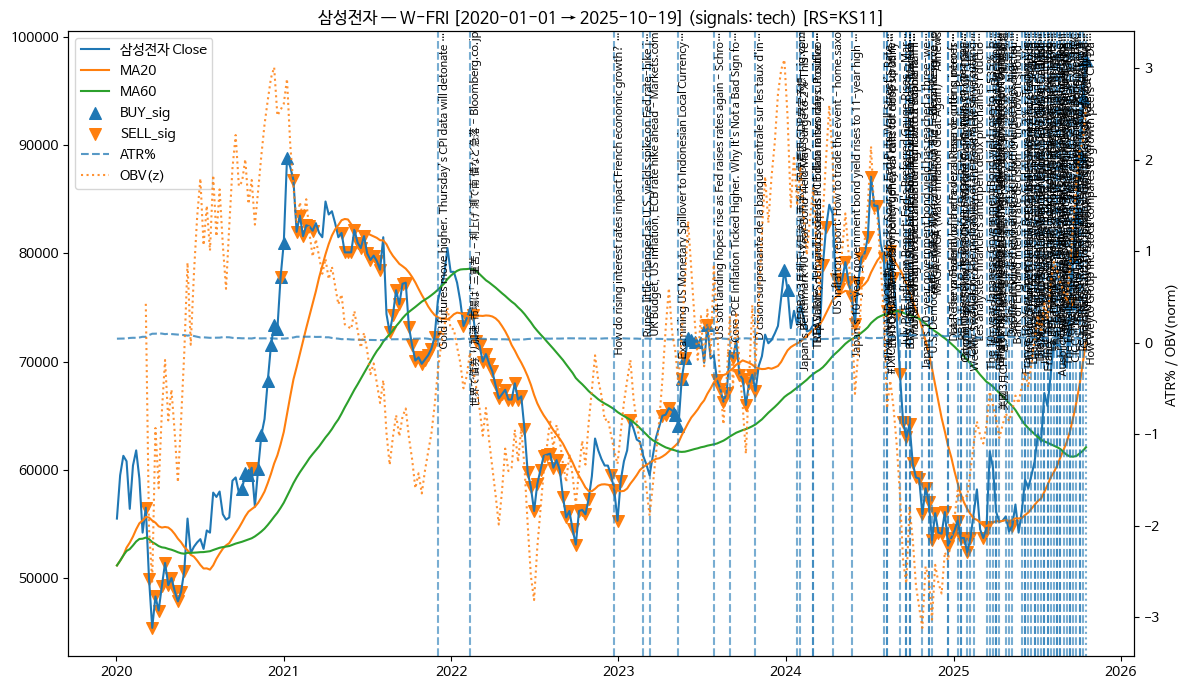

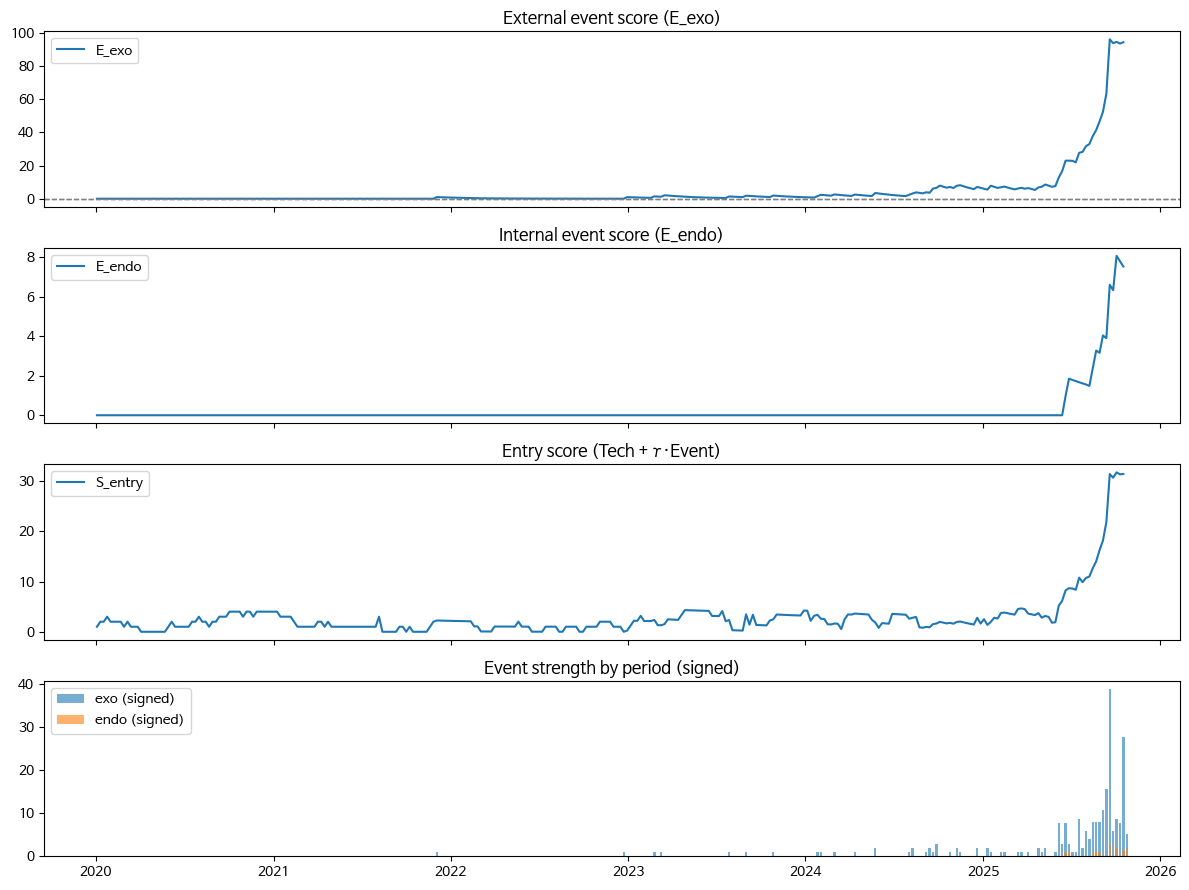

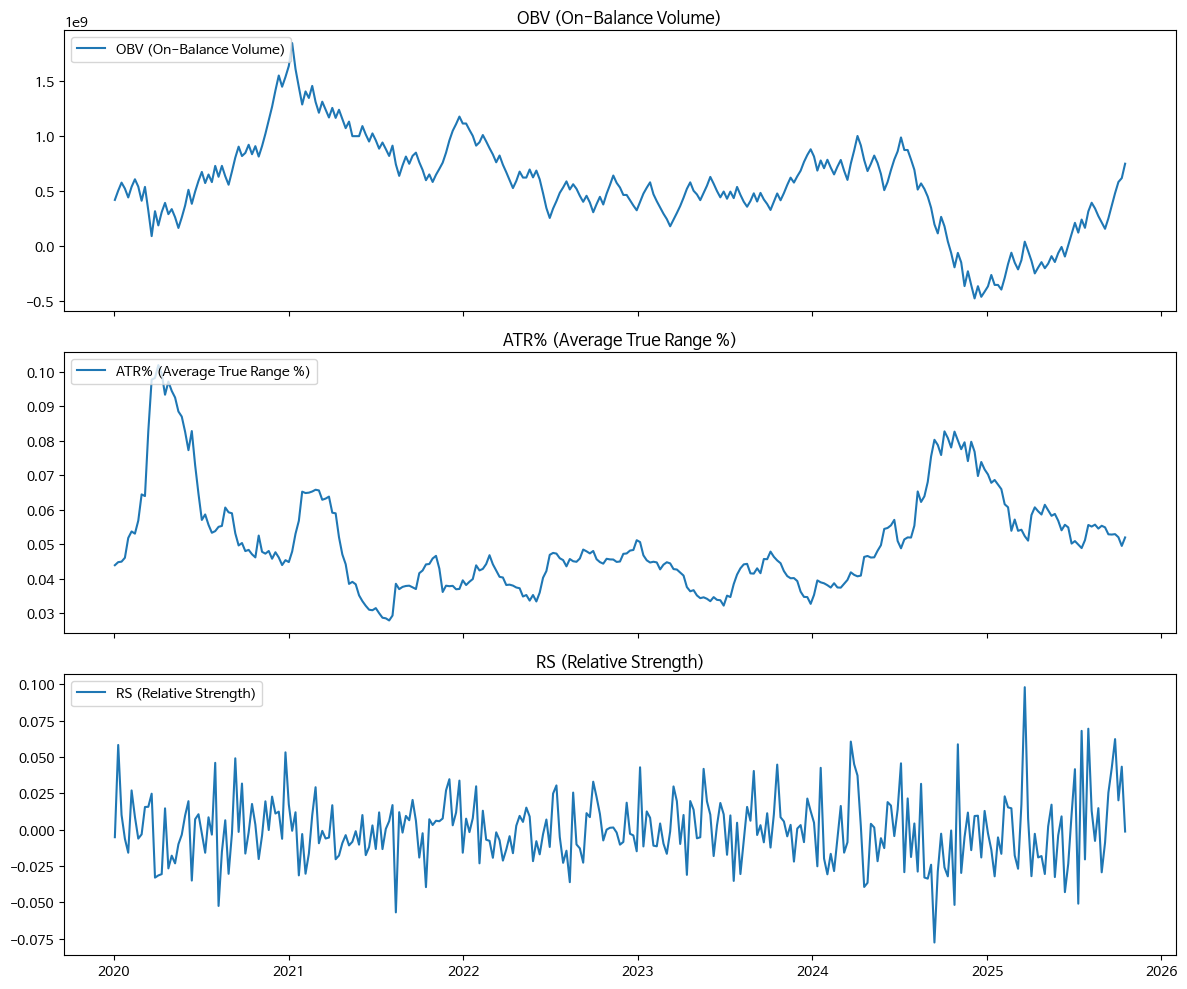

In [19]:
# 2) Event-only 정책 (이벤트가 없으면 의도적으로 거래 없음)
# OBV/ATR을 둘 다 끄고 싶다 → show만 False로
mix = plot_strategy_with_events(
    "005930",
    #name="삼성전자",
    basis="W-FRI",
    # events_df=None,
    events_df = events,
    params=EventRuleParams(theta_on=0.10, tau_buy=4, gamma=0.5, beta=0.5),
    signal_type="tech",
    start_date="2020-01-01", end_date="2025-10-19",
    warmup_days=120,
    show_obv=True, show_atr=True, show_rs=True   # ← 이것만으로 메인/보조 모두 OFF
)




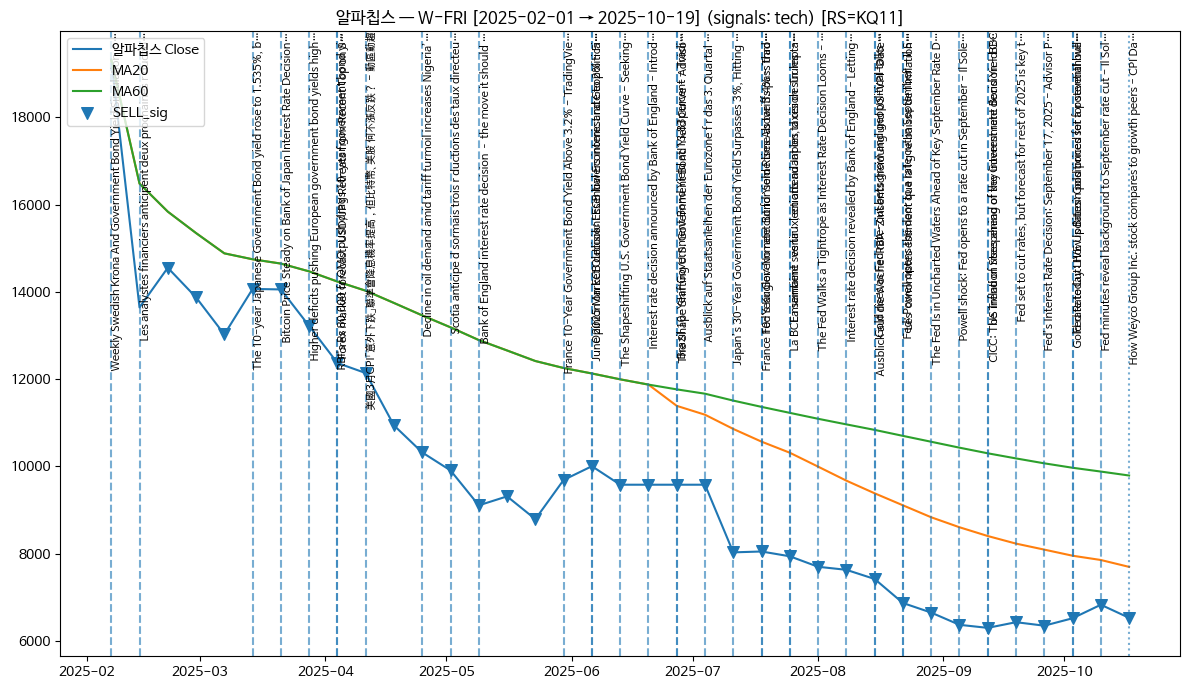

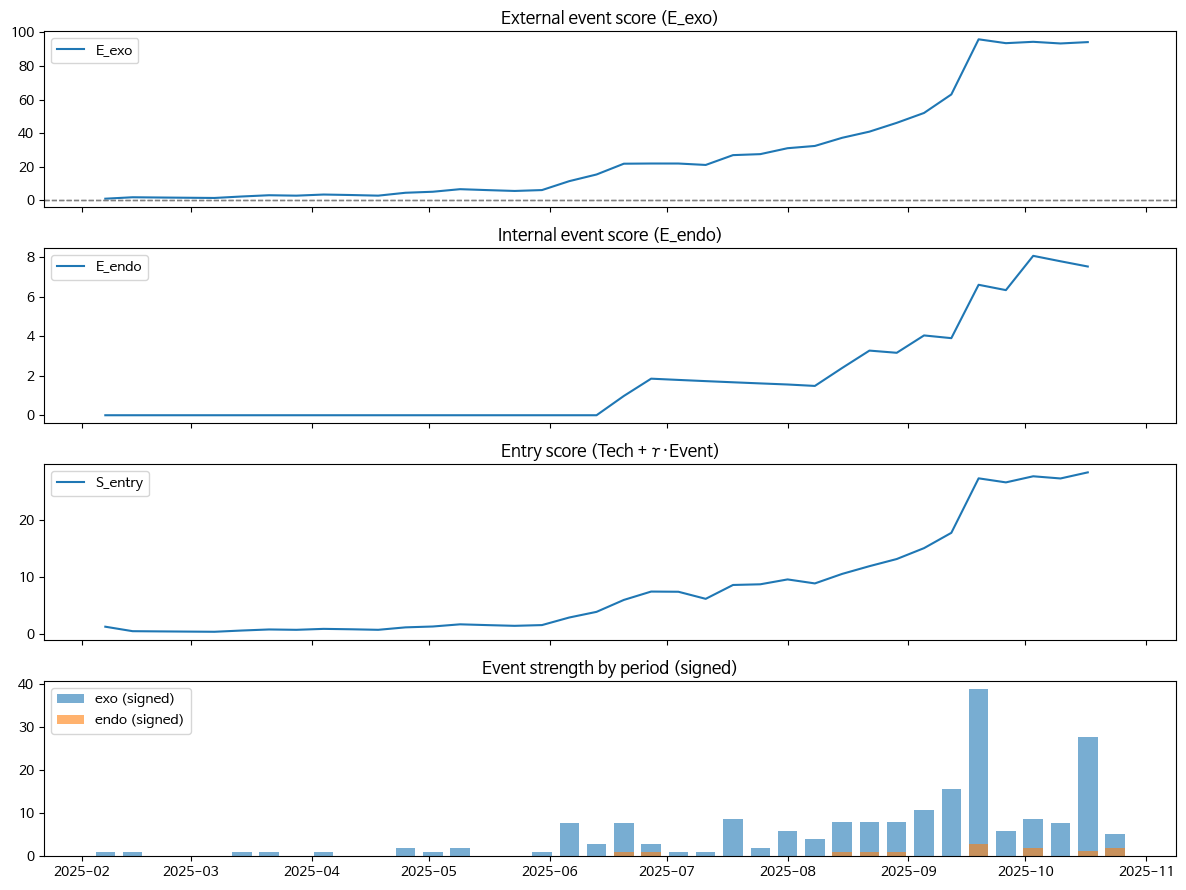

In [20]:
mix = plot_strategy_with_events("117670", name="알파칩스",
                                basis="W-FRI",
                                events_df=events, params=EventRuleParams(theta_on=0.10, tau_buy=4, gamma=0.5, beta=0.5),
                                signal_type="tech",
                                start_date="2025-02-01", end_date="2025-10-19")

In [21]:
# 강도를 추가한 파라메터로 전략 데이터프레임 조정
size_params = SizingParams(
    w_t=0.6, w_e=0.4, lambda_evt=1.2,
    atr_floor=0.012, risk_scale=0.6, w_max=1.0,
    use_kelly=True, kelly_frac=0.25, kelly_lookback=20, kelly_mix=0.3,
    riskon_penalty=0.6
)
mix = add_position_weights(mix, size_params)

In [22]:

# 3) 백테스트 (No-events)
bt_res, bt_perf = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=False,
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True, atr_floor=0.01, risk_scale=1.0,
    atr_stop_mult=None
)
bt_perf

{'CAGR': 0.0,
 'Sharpe': 0.0,
 'MaxDD': 0.0,
 '#Trades': 0,
 'WinRate': 0.0,
 'AnnVol': 0.0,
 'LastEquity': 1.0}

In [23]:

# 3) 백테스트 (Event-only)
bt_res, bt_perf = simulate_backtest_from_mix(
    mix, basis="W-FRI", exec_at="open",
    use_event_signals=True,
    fee_bps=10, slippage_bps=5,
    use_position_sizing=True, atr_floor=0.01, risk_scale=1.0,
    atr_stop_mult=None
)
bt_perf

{'CAGR': inf,
 'Sharpe': 0.0,
 'MaxDD': -0.00299774999999991,
 '#Trades': 9,
 'WinRate': 0.125,
 'AnnVol': nan,
 'LastEquity': inf}

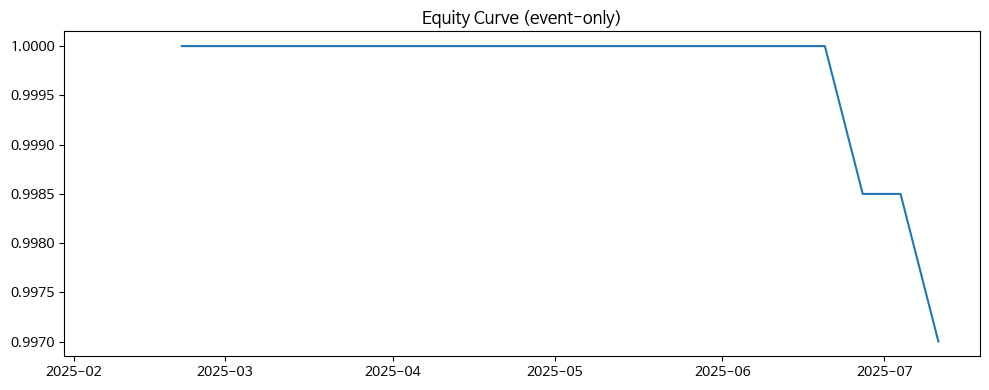

In [24]:
plt.figure(figsize=(10,4)); plt.plot(bt_res.index, bt_res["equity"]); plt.title("Equity Curve (event-only)"); plt.tight_layout(); plt.show()


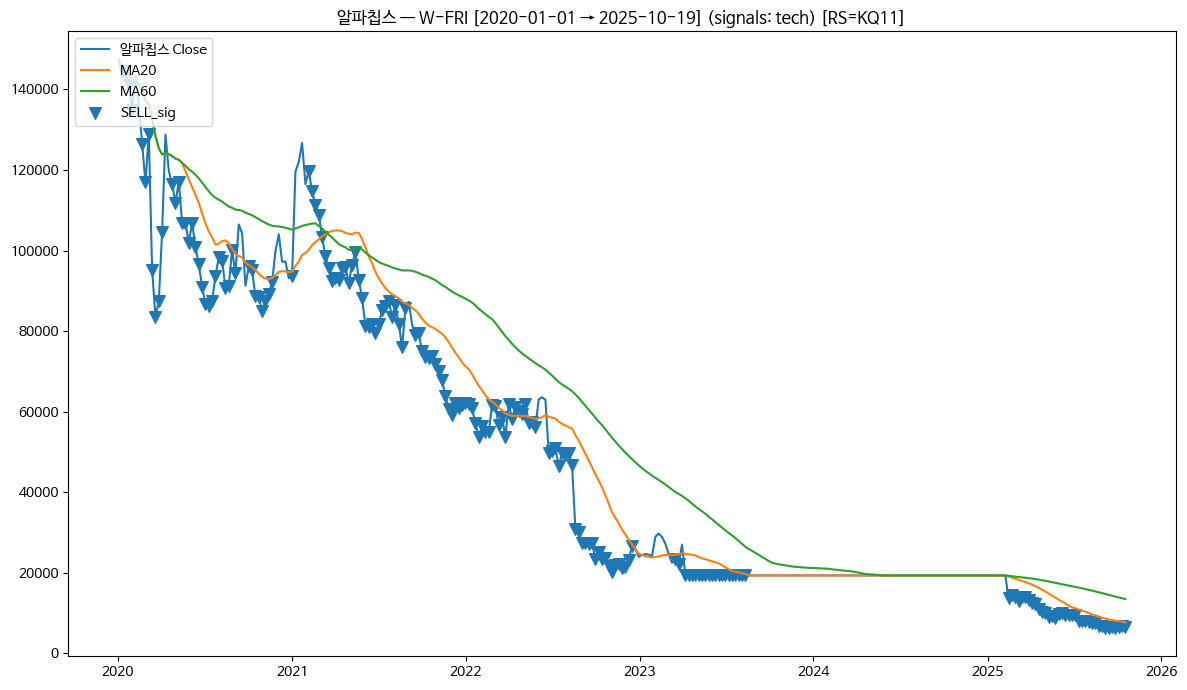

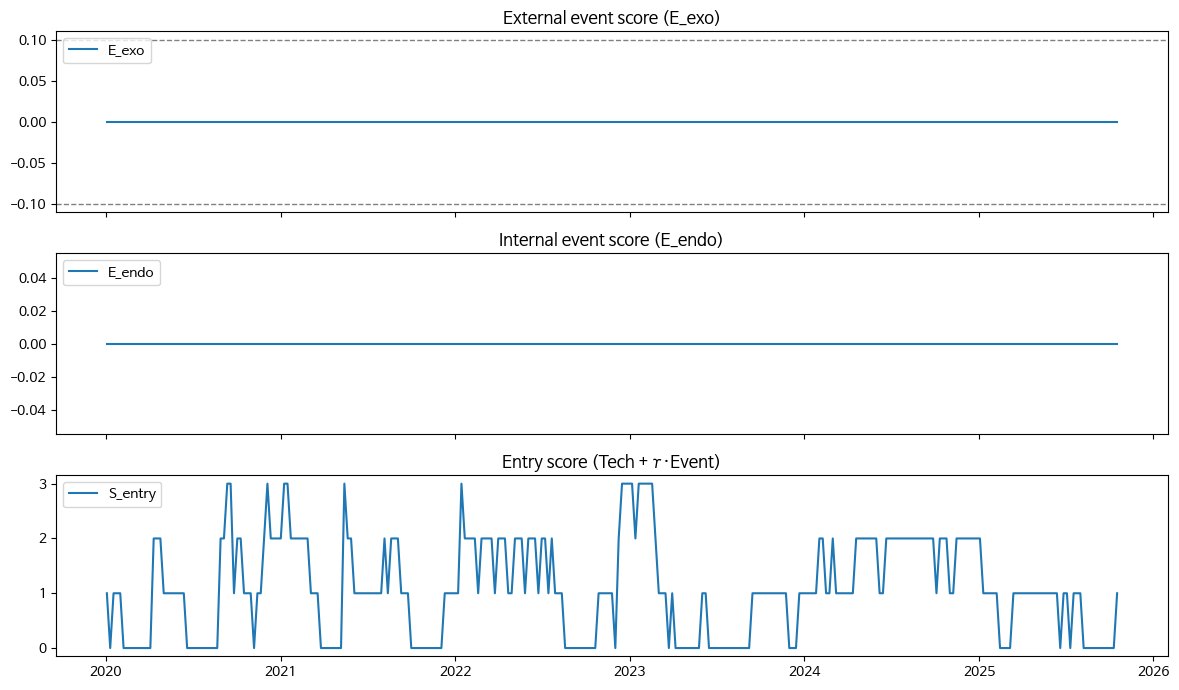

{'CAGR': 0.0,
 'Sharpe': 0.0,
 'MaxDD': 0.0,
 '#Trades': 0,
 'WinRate': 0.0,
 'AnnVol': 0.0,
 'LastEquity': 1.0}

In [25]:

# (B) 기술 실험 — 사용자가 명시적으로 허용할 때만
mix_tech = plot_strategy_with_events("117670", name="알파칩스",
                                basis="W-FRI", rs_index_code="KQ11",
                                events_df=None, params=EventRuleParams(m1=20, m2=60),
                                use_imputed=True, signal_type="tech",
                                show_agg_bar=False)

bt_res2, bt_perf2 = simulate_backtest_from_mix(
    mix_tech, basis="W-FRI", exec_at="open",
    use_event_signals=False,  # 기술 신호
    fee_bps=10, slippage_bps=5, use_position_sizing=True
)
bt_perf2


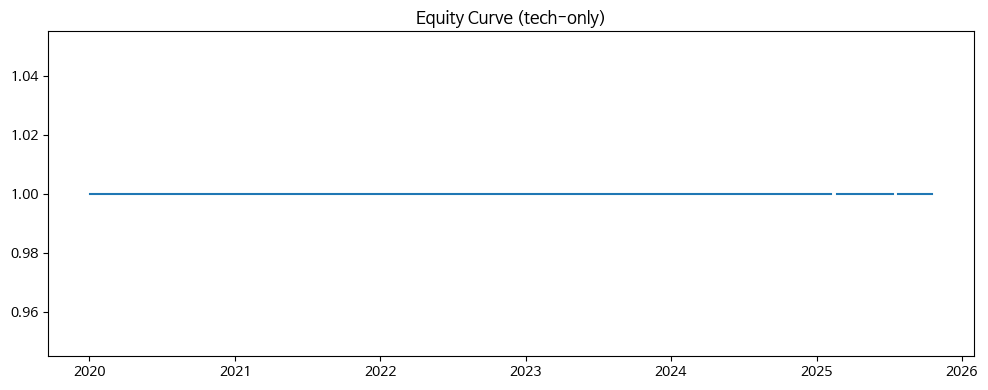

In [26]:
plt.figure(figsize=(10,4)); plt.plot(bt_res2.index, bt_res2["equity"]); plt.title("Equity Curve (tech-only)"); plt.tight_layout(); plt.show()


# 멀티 비교 예시(옵션)

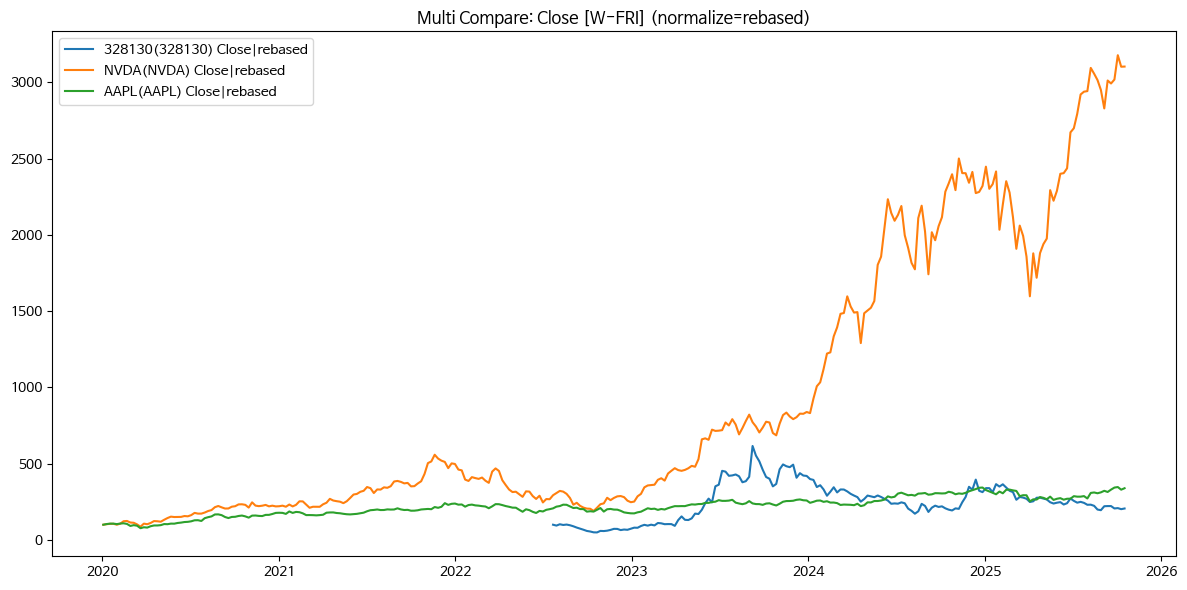

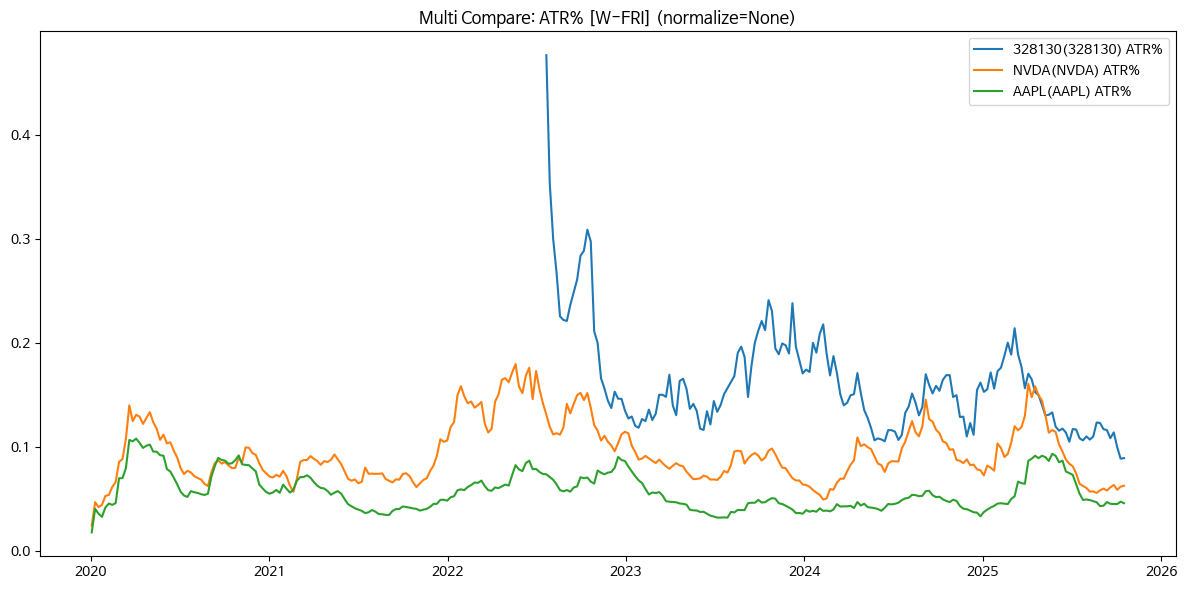

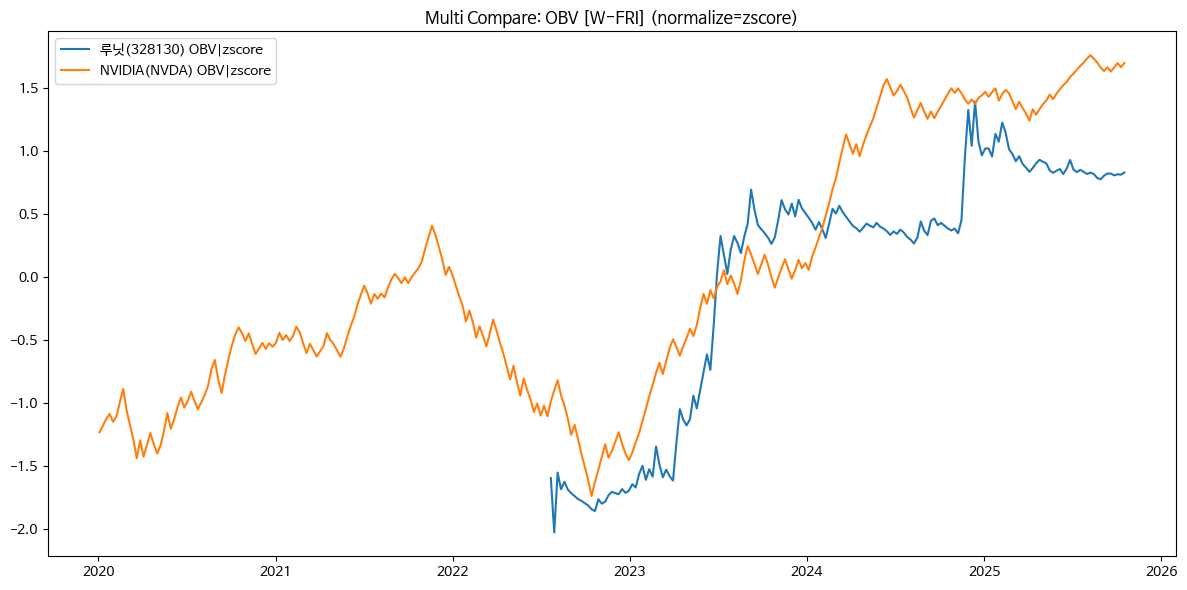

In [27]:
# 가격 리베이스 비교
plot_multi_compare(["328130","NVDA","AAPL"], basis="W-FRI", field="Close", normalize="rebased")
# 변동성(ATR%) 비교
plot_multi_compare(["328130","NVDA","AAPL"], basis="W-FRI", field="ATR%", normalize=None)
# OBV z-score 비교
plot_multi_compare({"루닛":"328130","NVIDIA":"NVDA"}, basis="W-FRI", field="OBV", normalize="zscore")


# 이벤트 강도를 줄이기 위한 방식(주단위 유지)

A) “저소음(Lo-noise) 주간” 프리셋

주 단위 유지하면서 강한 이벤트만 남긴다.

basis="W-FRI"(그대로)

이벤트 필터: quantile 97% 이상만 표시

이벤트 영향 약화: gamma ↓, 반감기 ↓

리스크 온/오프 문턱 강화

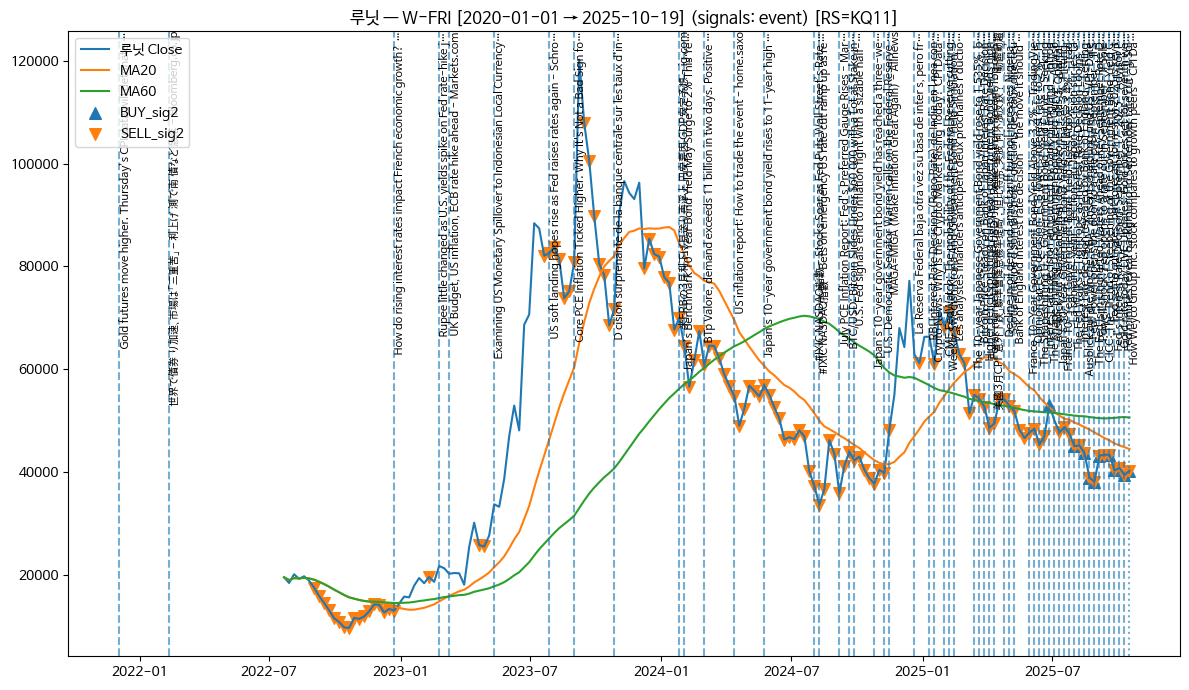

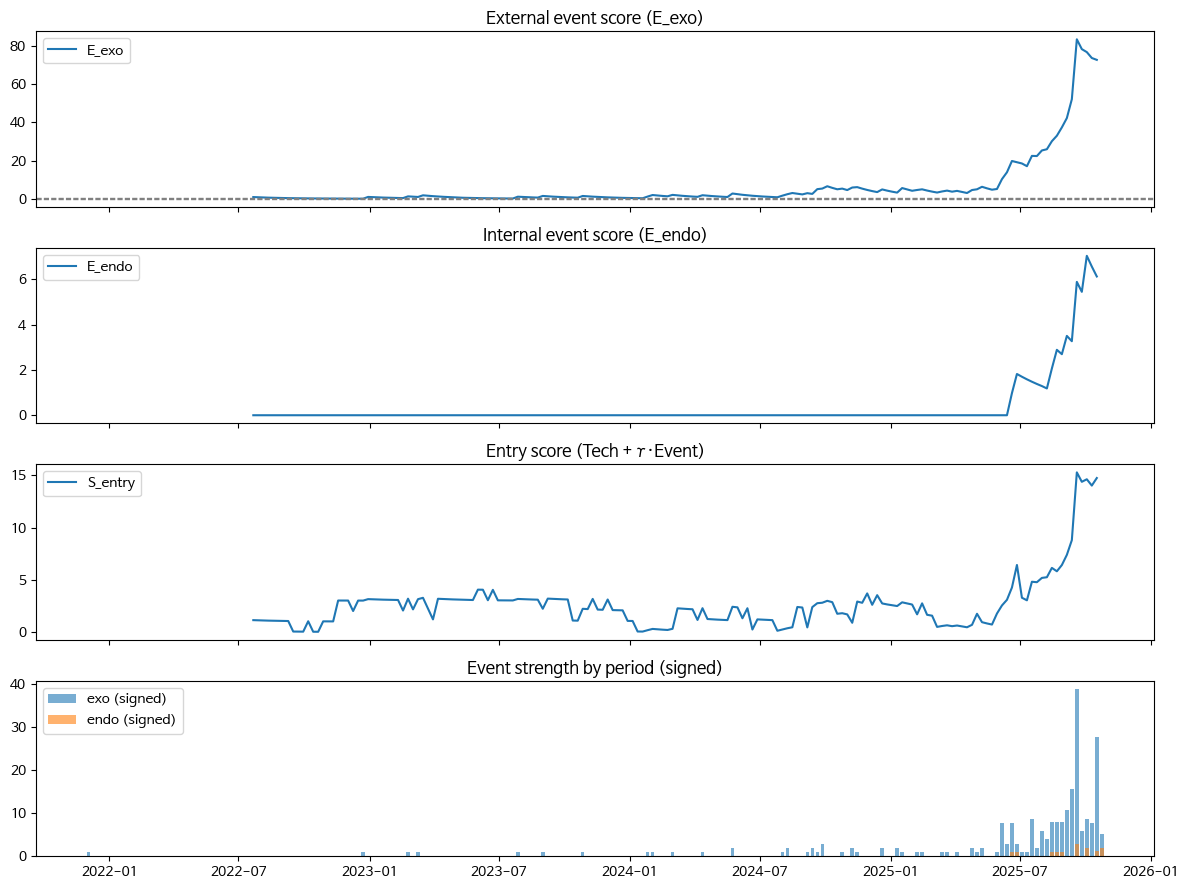

In [28]:
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,
    gamma=0.30,            # 이벤트 반영도 축소
    tau_buy=5,             # 진입 더 보수적
    theta_on=0.15,         # 리스크온 조건 강화
    theta_off=-0.15,       # 리스크오프 조건 강화
    half_life_exo=5,       # 이벤트 잔향 빨리 소멸
    half_life_endo=10
)

mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="quantile",  # 핵심: 상위 분위수만 표시
    event_q=0.97,                  # 97% 이상만 남김
    show_agg_bar=True
)


B) “2주 압축(2W)” 프리셋

주간이 여전히 복잡하면 2주 단위로 압축.

basis="2W-FRI"

이벤트 필터: Top-K=1 (기간×유형별 1건만)

이벤트 영향 더 약화

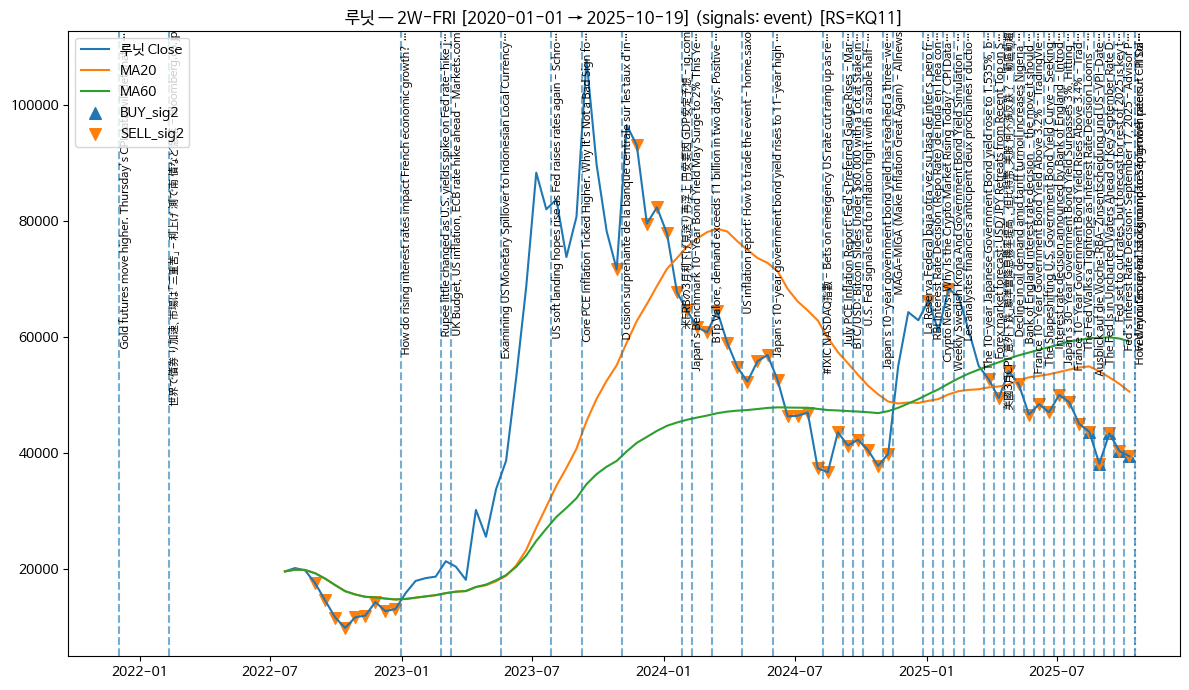

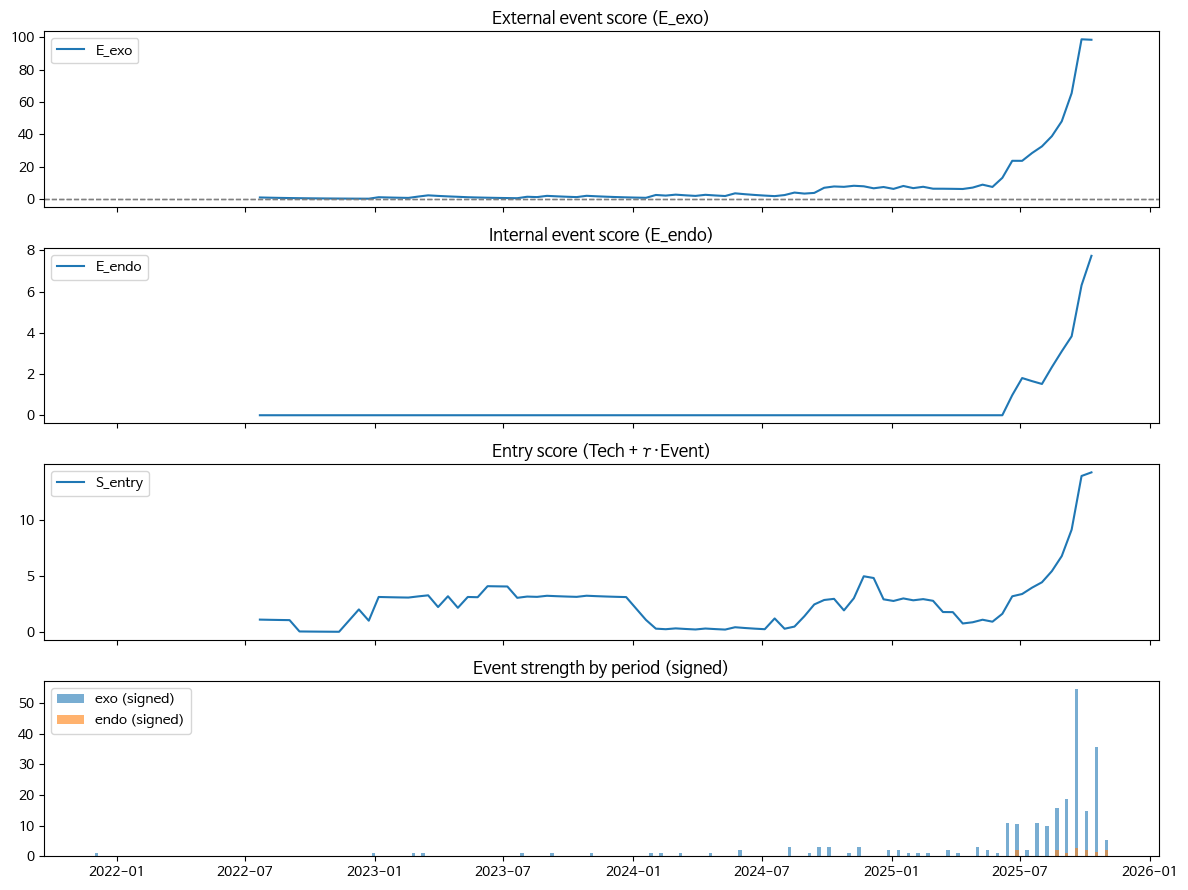

In [29]:
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,
    gamma=0.25,
    tau_buy=5,
    theta_on=0.18,
    theta_off=-0.18,
    half_life_exo=4,
    half_life_endo=8
)

mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="2W-FRI", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="topk",     # 핵심: 각 기간·유형당 1건
    event_top_k=1,
    show_agg_bar=True
)


C) “월간 핵심(Monthly core)” 프리셋

월 단위로 묶어서 아주 소수의 이벤트만 본다.

basis="M"

이벤트 필터: Top-K=1 또는 quantile=0.99

이벤트 영향 최소화

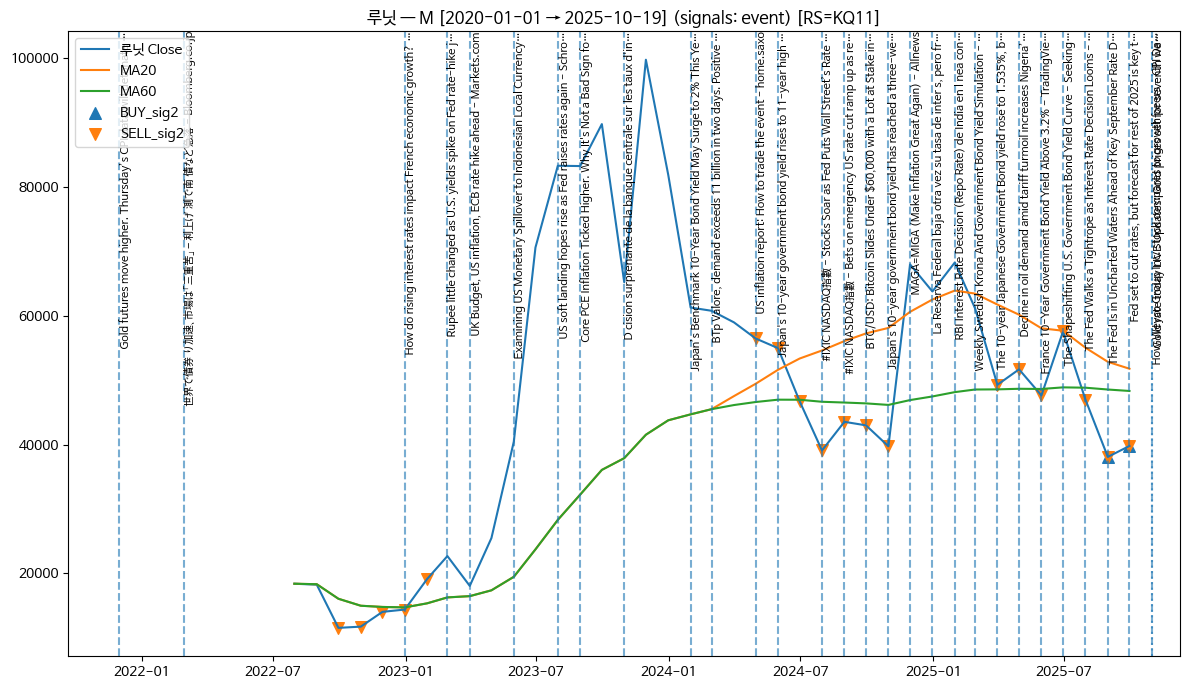

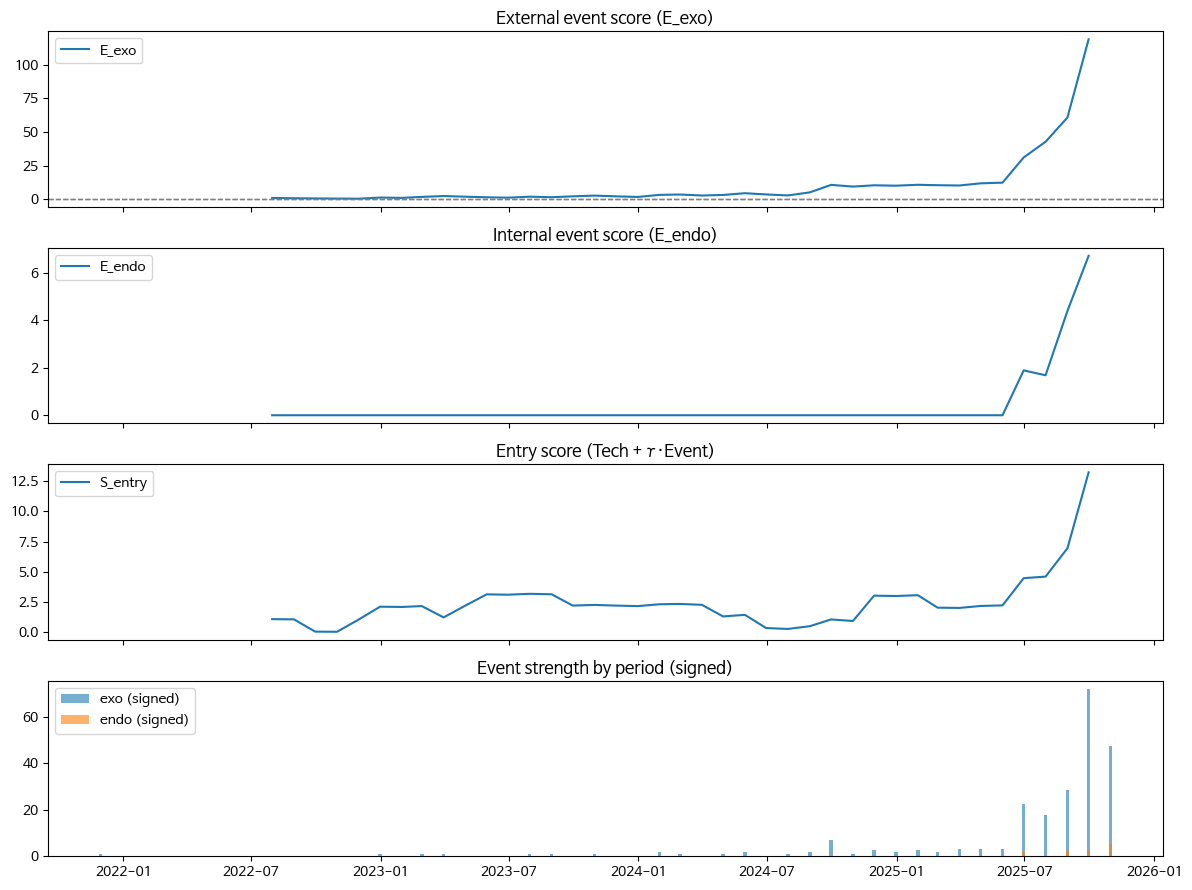

In [30]:
params = EventRuleParams(
    m1=20, m2=60,
    alpha=1.0, beta=0.5,
    gamma=0.20,
    tau_buy=6,
    theta_on=0.20,
    theta_off=-0.20,
    half_life_exo=3,
    half_life_endo=6
)

mix = plot_strategy_with_events(
    "328130", name="루닛",
    basis="M", rs_index_code="KQ11",
    events_df=events, params=params,
    signal_type="event",
    event_filter_mode="topk",   # 또는 "quantile", event_q=0.99
    event_top_k=1,
    show_agg_bar=True
)


# 이벤트 어댑터 사용 가이드 (build_event_adapter / apply_adaptive_gamma)

> 목적: **시대·섹터별 뉴스의 ‘부족/과다’ 왜곡**을 줄이기 위해, 이벤트 영향력(γ)과/또는 이벤트 점수(E_event)를 **시간가변으로 감쇠/증폭**한다.
> 결과: 이벤트가 **적거나 과한 구간**에서도 분석이 안정화되고, 이벤트 수집 누수/스팸에 덜 휘둘린다.

---

## 0) 전제(데이터 스키마)

* `events_df`(또는 `ev_slice`)는 최소 아래 컬럼을 권장:

  * `date` (datetime-like, 필수)
  * `etype` ∈ {`"exo"`, `"endo"`} (권장)
  * `strength` (옵션, 가중 평균 등에 사용)
  * `source` (옵션, 출처 가중 사용 시)
  * `title` 또는 `url` (옵션, **중복 판단**에 사용)
* `mix`: `plot_strategy_with_events(...)`가 반환하는 DataFrame. 최소 `EntryScore`, `E_event`가 존재.

---

## 1) 개념 요약

* **q_t ∈ [0,1]** (기간별 가중)을 만든다:

  * **밀도(dens)**: 기간당 이벤트 개수(상한 cap으로 정규화)
  * **중복(uniq)**: 같은 기간 내 **고유 비율** (제목/URL 중복이 적을수록 ↑)
  * **커버리지(coverage)**: 롤링 윈도 내 이벤트가 **존재한 기간 비율**
  * (옵션) **소스 품질(q_source)**: 출처 가중 평균 (이미 스코어에 반영돼 있으면 **끄기**)
* 이 q_t로

  * **기본**: `γ_eff = γ0 × q_t` (**γ만** 시간가변 조정)
  * **옵션**: `E_event_adj = E_event × q_t` (점수 자체도 감쇠)
* 최종 진입점수 재계산:
  `S_entry = EntryScore + γ_eff × E_event_adj`

---

## 2) API

### 2.1 `build_event_adapter(...) -> pd.DataFrame`

기간별 요약 테이블 생성. `index=가격 시계열 인덱스`.

**시그니처**

```python
build_event_adapter(
    ev_slice: pd.DataFrame,
    price_index: pd.DatetimeIndex,
    basis: str = "W-FRI",
    cap_per_period: int = 2,
    roll_periods: int = 104,
    min_cov: float = 0.2,
    alpha: float = 0.5,
    beta: float  = 0.5,
    source_weight: dict | None = None,
    source_power: float = 1.0
) -> pd.DataFrame
```

**리턴 컬럼**

* `n`: 기간 이벤트 개수
* `dens`: 상한 cap으로 정규화된 밀도(과밀 구간은 완만 페널티)
* `uniq`: 고유 비율(중복이 적을수록 1에 가까움)
* `q_source`: 소스 가중 평균(미사용 시 1.0)
* `coverage`: 롤 윈도 내 이벤트 존재 비율
* `q`: 최종 가중
  `q = (dens^alpha) * (uniq^beta) * (q_source^source_power)`
  (coverage < min_cov이면 **추가 감쇠**)

> **이중가중 방지**: 이벤트 스코어링에 이미 소스 가중이 들어갔다면
> `source_weight=None` **또는** `source_power=0.0`로 **끄라**.

---

### 2.2 `apply_adaptive_gamma(...) -> (mix_out, adapter_df)`

q_t를 이용해 `γ_eff`와 `E_event_adj`(옵션)를 반영하고, `S_entry`를 재계산한다.

**시그니처**

```python
apply_adaptive_gamma(
    mix: pd.DataFrame,
    ev_slice: pd.DataFrame,
    basis: str,
    gamma0: float = 0.4,
    mode: str = "gamma_only",   # "gamma_only" | "both"
    **adapter_kwargs
) -> tuple[pd.DataFrame, pd.DataFrame]
```

**파라미터 핵심**

* `mode="gamma_only"`: **γ만** 조정(권장) — 기존 E_event 해석을 보존, 이중가중 위험↓
* `mode="both"`: γ와 E_event를 모두 감쇠/증폭 — **노이즈가 매우 심할 때만**

**리턴**

* `mix_out`: `mix` + `gamma_eff`, `E_event_adj`, `S_entry`(재계산)
* `adapter_df`: 위 `build_event_adapter`의 요약 테이블

---

## 3) 퀵스타트

```python
# 1) mix 생성 (기존 파이프라인)
mix = plot_strategy_with_events(
    "117670", basis="W-FRI",
    events_df=events, params=params, signal_type="event",
    start_date="2016-01-01", end_date="2025-10-01",
    warmup_days=120,
    show_obv=False, show_atr=False, show_rs=False
)

# 2) 어댑터 적용 — 이미 소스 가중이 스코어에 반영됐다면 source_power=0.0
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, ev_slice=events, basis="W-FRI",
    gamma0=params.gamma,
    mode="gamma_only",           # γ만 조정(권장)
    cap_per_period=2,
    roll_periods=104, min_cov=0.2,
    alpha=0.6, beta=0.6,
    source_weight=None,          # 또는 유지하되
    source_power=0.0             # ← 소스 영향 무효(이중가중 방지)
)

# 3) 확인
ev_adapt[["n","dens","uniq","coverage","q"]].tail()
mix_adj[["EntryScore","E_event","gamma_eff","E_event_adj","S_entry"]].tail()
```

---

## 4) 모드/시나리오별 사용 예

### A) **소스 가중 이미 반영** → 이중가중 방지

```python
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, events, "W-FRI",
    gamma0=params.gamma, mode="gamma_only",
    cap_per_period=2, roll_periods=104, min_cov=0.2,
    alpha=0.6, beta=0.6,
    source_weight=None, source_power=0.0
)
```

### B) **소스 품질까지 반영**(출처 신뢰도 활용)

```python
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, events, "W-FRI",
    gamma0=params.gamma, mode="gamma_only",
    cap_per_period=2, roll_periods=104, min_cov=0.2,
    alpha=0.6, beta=0.6,
    source_weight={"Reuters":1.0,"Bloomberg":1.0,"Yonhap":0.9,"BlogX":0.6},
    source_power=1.0    # 완만하게 0.5 등도 가능
)
```

### C) **뉴스 과밀·스팸 심함** → 점수 자체도 감쇠

```python
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, events, "D",
    gamma0=params.gamma, mode="both",   # γ와 E_event 모두 q로 조정
    cap_per_period=3, roll_periods=252, min_cov=0.3,
    alpha=0.7, beta=0.7,
    source_power=0.0
)
```

---

## 5) 파라미터 가이드

| 파라미터             | 의미                  | 권장 범위/기본                          |
| ---------------- | ------------------- | --------------------------------- |
| `cap_per_period` | 기간당 이벤트 수 상한(과밀 억제) | W: 1–3 / D: 2–5 / M: 1–2          |
| `alpha`          | 밀도(dens) 민감도        | 0.4–0.8 (기본 0.5~0.6)              |
| `beta`           | 중복(uniq) 민감도        | 0.4–0.8 (기본 0.5~0.6)              |
| `roll_periods`   | 커버리지 롤 윈도           | D: 252(1Y), W: 104(2Y), M: 24(2Y) |
| `min_cov`        | 커버리지 하한             | 0.2–0.4                           |
| `source_weight`  | 출처별 신뢰도             | 스코어에 이미 반영됐으면 **None**            |
| `source_power`   | 소스가중 영향 지수          | **0.0**(무효) ~ 1.0(그대로)            |
| `mode`           | γ만/둘 다 조정           | `"gamma_only"`(권장) / `"both"`     |

> **기본 추천(주봉)**: `cap_per_period=2`, `alpha=0.6`, `beta=0.6`, `roll_periods=104`, `min_cov=0.2`, `mode="gamma_only"`

---

## 6) 파이프라인 통합

1. `plot_strategy_with_events(...)` → `mix`
2. `apply_adaptive_gamma(...)` → `mix_adj` (γ_eff, E_event_adj, S_entry 반영)
3. (선택) `add_position_weights(mix_adj, size_params)` → `w_target` 비중 생성
4. `simulate_backtest_from_mix(mix_adj, use_event_signals=True, ...)`

> **워크-포워드(OOS) 검증**: 각 Train 구간에서 `ev_adapt`의 롤링 통계(coverage 등)를 계산하고, 다음 Test 구간에 **고정 적용**(누수 방지).

---

## 7) 해석 팁

* `coverage`↓(이벤트 부족 구간) → `q`↓ → `gamma_eff`↓ → **기술 신호 중심**으로 자동 전환
* `n`↑ & `uniq`↓(스팸/중복) → `q`↓ → 이벤트 과잉 영향 억제
* `source_power=0.0`로 두면 **이미 반영된 소스 가중**을 **다시 곱하지 않음**(안전)

---

## 8) 흔한 실수 / 빠른 해결

* **차트에 이벤트가 너무 많다** → 원래 라벨 필터(`event_filter_mode="topk"/"quantile"/"threshold"`)와 **동시에** 어댑터 `cap_per_period`를 낮춰라.
* **옛 구간은 이벤트 거의 0** → `min_cov`를 0.2~0.3으로 두면 자동 감쇠돼 왜곡 감소.
* **소스 가중이 이중 반영** → `source_power=0.0` 또는 `source_weight=None`.
* **D/W/M 혼동** → `roll_periods`를 **basis에 맞춰** 조정(D:252, W:104, M:24).

---

#이벤트 품질·밀도 어댑터

In [41]:
# 필요 모듈
import pandas as pd
import numpy as np

def build_event_adapter(
    ev_slice: pd.DataFrame,
    price_index: pd.DatetimeIndex,
    basis: str = "W-FRI",
    cap_per_period: int = 2,          # 기간당 이벤트 수 상한(과밀 억제)
    roll_periods: int = 104,          # 커버리지 롤 윈도(예: 주봉 2년=104)
    min_cov: float = 0.2,             # 커버리지 하한(coverage < min_cov 이면 추가 감쇠)
    alpha: float = 0.5,               # 밀도(dens) 민감도
    beta: float  = 0.5,               # 중복(uniq) 민감도
    source_weight: dict | None = None,# {"Reuters":1.0,"BlogX":0.6} 등 (이미 스코어에 반영돼 있으면 None)
    source_power: float = 1.0         # 0.0이면 소스가중 무효(이중가중 방지)
) -> pd.DataFrame:
    """
    이벤트 품질/밀도/커버리지를 바탕으로 기간별 가중 q_t ∈ [0,1]을 계산하여 반환합니다.
    반환 DataFrame(index=price_index) 컬럼:
      - n        : 기간 이벤트 개수
      - dens     : cap 정규화된 밀도(과밀 구간 추가 완만 페널티 포함)
      - uniq     : 고유 비율(중복 적을수록 1에 가까움; title/url 기준)
      - q_source : 소스 가중 평균(미사용 시 1.0)
      - coverage : 롤 윈도 내 이벤트 존재 비율
      - q        : 최종 가중 = (dens^alpha)*(uniq^beta)*(q_source^source_power)
                    (coverage < min_cov이면 q *= coverage/min_cov 로 추가 감쇠)
    ※ tz-aware/naive 불일치로 매칭 실패하지 않도록 price_index/이벤트 시간을 tz-naive로 강제 정규화합니다.
    """

    # --- 0) 출력 스켈레톤 (모든 값 0으로 초기화) ---
    # price_index를 tz-naive로 강제
    if not isinstance(price_index, pd.DatetimeIndex):
        price_index = pd.DatetimeIndex(pd.to_datetime(price_index, errors="coerce"))
    else:
        try:
            # tz-aware → tz-naive
            price_index = price_index.tz_localize(None)
        except Exception:
            # 이미 tz-naive 이거나 변환 불가면 그대로
            pass
        price_index = pd.DatetimeIndex(pd.to_datetime(price_index, errors="coerce"))

    out = pd.DataFrame(index=price_index,
                       columns=["n","dens","uniq","q_source","q","coverage"],
                       dtype=float)
    out.loc[:, ["n","dens","uniq","q_source","q","coverage"]] = 0.0

    # 이벤트가 없으면 바로 반환
    if ev_slice is None or len(ev_slice) == 0:
        return out

    # --- 1) 이벤트 전처리 (tz-naive 정규화 + 기간 버킷) ---
    ev = ev_slice.copy()
    ev["date"] = pd.to_datetime(ev["date"], errors="coerce")
    ev = ev.dropna(subset=["date"])
    # tz-aware → tz-naive
    try:
        ev["date"] = ev["date"].dt.tz_localize(None)
    except Exception:
        pass

    # basis → pandas Period freq 매핑
    b = (basis or "").upper()
    if b.startswith("2W"):          # 2주 주기
        freq = "2W-FRI"
    elif b.startswith("W"):         # 주간(금요일 고정)
        freq = "W-FRI"
    elif b.startswith("M"):         # 월간
        freq = "M"
    else:                           # 일간
        freq = "D"

    # 기간 끝(예: W-FRI → 해당 금요일 00:00)으로 정렬하여 price_index와 정합성↑
    ev["period"] = ev["date"].dt.to_period(freq).dt.to_timestamp(how="end")

    # --- 2) 기간별 집계: 개수/중복/소스품질 ---
    grp = ev.groupby("period", sort=True)
    n = grp.size().rename("n")

    # 중복 판단 키(있으면 사용)
    dup_key = "title" if "title" in ev.columns else ("url" if "url" in ev.columns else None)
    if dup_key:
        uniq = (grp[dup_key].nunique() / grp.size()).rename("uniq")  # 0~1, 중복 적을수록 1에 근접
    else:
        uniq = pd.Series(1.0, index=n.index, name="uniq")

    # 소스 가중 평균(미사용 시 1.0)
    if source_weight and ("source" in ev.columns):
        w = ev.assign(sw=ev["source"].map(source_weight).fillna(0.7))
        q_src = w.groupby("period")["sw"].mean().rename("q_source")
    else:
        q_src = pd.Series(1.0, index=n.index, name="q_source")

    # --- 3) 밀도(dens) 계산 + 과밀 페널티 ---
    dens = (n.clip(upper=cap_per_period) / float(cap_per_period)).rename("dens")
    over_mask = (n > (2 * cap_per_period))
    if over_mask.any():
        dens.loc[over_mask] = dens.loc[over_mask] * np.sqrt((2 * cap_per_period) / n.loc[over_mask])

    # --- 4) 가격 인덱스로 정렬(reindex) ---
    # period 집계표 → price_index에 맞춰 정렬(존재하지 않는 날짜는 0)
    perf = pd.concat([n, dens, uniq, q_src], axis=1)
    perf = perf.reindex(price_index).fillna(0.0)

    # --- 5) 커버리지(롤링 윈도 내 이벤트 존재 비율) ---
    hits = (perf["n"] > 0).astype(float)
    # min_periods는 과도한 NaN을 피하기 위해 윈도의 1/8 이상으로 설정
    coverage = hits.rolling(roll_periods, min_periods=max(4, roll_periods // 8)).mean().fillna(0.0)

    # --- 6) 최종 q 계산 + 커버리지 추가 감쇠 ---
    # q = (dens^alpha) * (uniq^beta) * (q_source^source_power)
    q = (perf["dens"].pow(alpha)) * (perf["uniq"].pow(beta)) * (perf["q_source"].pow(source_power))
    # coverage < min_cov → q *= coverage / min_cov
    safe_min_cov = max(min_cov, 1e-6)
    q = np.where(coverage < safe_min_cov, q * (coverage / safe_min_cov), q)
    q = pd.Series(q, index=perf.index, name="q")

    # --- 7) 결과 결합/반환 ---
    out.update(pd.DataFrame({
        "n": perf["n"].astype(float),
        "dens": perf["dens"].astype(float),
        "uniq": perf["uniq"].astype(float),
        "q_source": perf["q_source"].astype(float),
        "coverage": coverage.astype(float),
        "q": q.astype(float),
    }, index=perf.index))
    return out


# mix에 적응형 γ 적용

In [32]:
def apply_adaptive_gamma(
    mix: pd.DataFrame,
    ev_slice: pd.DataFrame,
    basis: str,
    gamma0: float = 0.4,
    mode: str = "gamma_only",       # "gamma_only" | "both"
    **adapter_kwargs
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    mix에 '적응형 이벤트 영향'을 반영한다.
      - gamma_only: γ만 시간가변(q_t)으로 조정(권장: 이중가중 방지, 철학 보존)
      - both      : γ와 E_event 모두 q_t로 조정(노이즈가 매우 심할 때)
    반환: (mix_out, adapter_df)
      - mix_out: 기존 mix + ["gamma_eff","E_event_adj","S_entry"(재계산)]
      - adapter_df: build_event_adapter의 요약 테이블(n, dens, uniq, q_source, coverage, q)
    """
    out = mix.copy()
    adapter = build_event_adapter(ev_slice, price_index=out.index, basis=basis, **adapter_kwargs)
    q = adapter["q"].reindex(out.index).fillna(0.0)

    out["gamma_eff"] = gamma0 * q

    if mode == "both":
        out["E_event_adj"] = out.get("E_event", 0.0) * q
    else:  # "gamma_only"
        out["E_event_adj"] = out.get("E_event", 0.0)

    out["S_entry"] = out.get("EntryScore", 0.0) + out["gamma_eff"] * out["E_event_adj"]
    return out, adapter


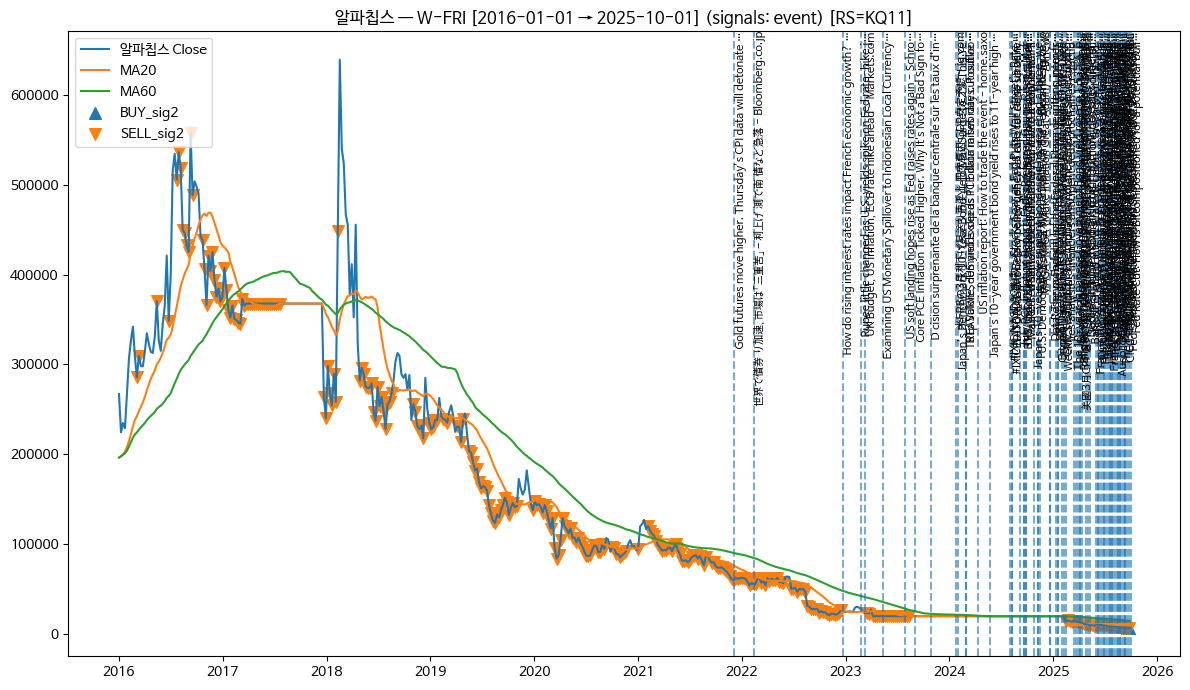

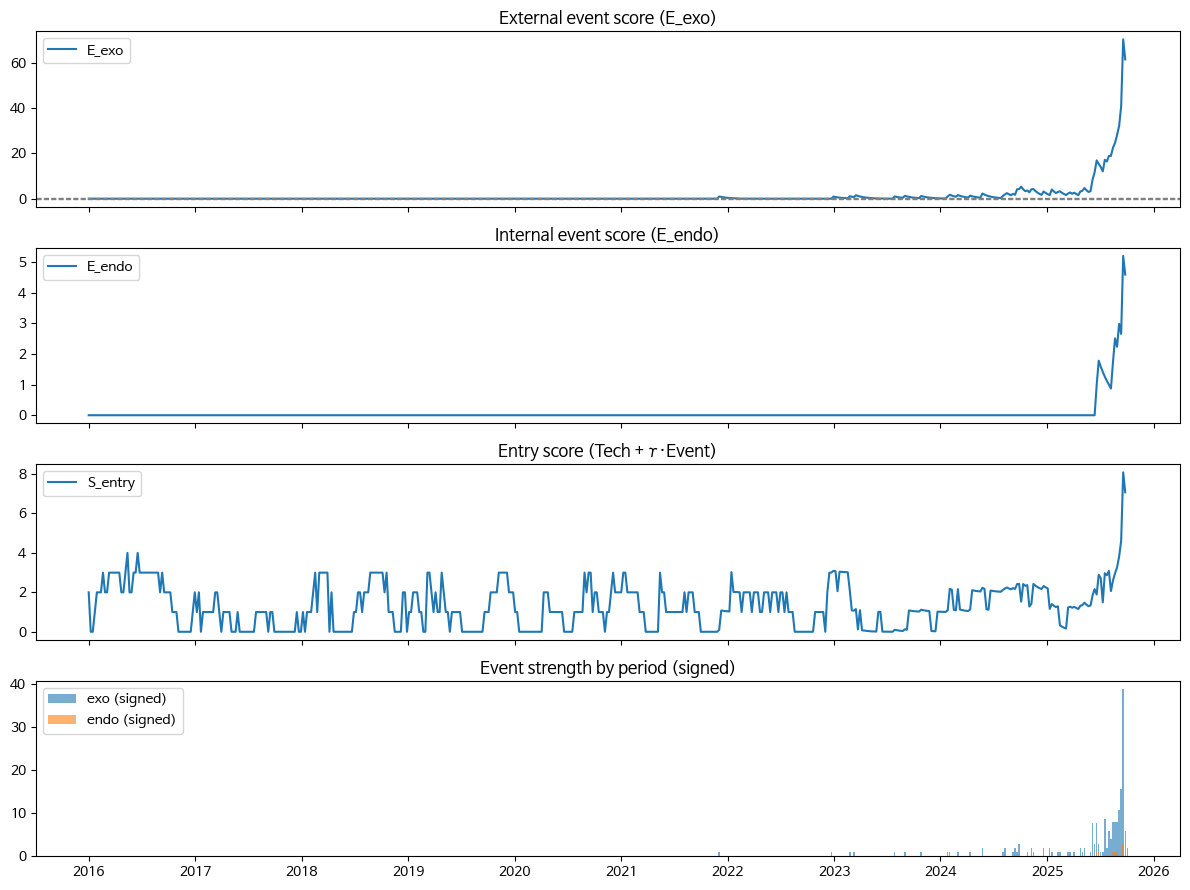

,EntryScore,E_event,gamma_eff,E_event_adj,S_entry
Date,,,,,
2025-08-29,0,16.333865,0.0,16.333865,0.0
2025-09-05,0,19.025039,0.0,19.025039,0.0
2025-09-12,0,23.053802,0.0,23.053802,0.0
2025-09-19,0,40.427449,0.0,40.427449,0.0
2025-09-26,0,35.374673,0.0,35.374673,0.0


In [33]:
# 1) 기존 파이프라인으로 mix 생성
mix = plot_strategy_with_events(
    "117670", basis="W-FRI",
    events_df=events, params=params, signal_type="event",
    start_date="2016-01-01", end_date="2025-10-01",
    warmup_days=120,
    show_obv=False, show_atr=False, show_rs=False
)

# 2) 어댑터 적용 (소스가중 끔: source_power=0.0)
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, ev_slice=events, basis="W-FRI",
    gamma0=params.gamma,           # 기존 γ 사용
    mode="gamma_only",             # ★ γ만 조정 (권장)
    cap_per_period=2,
    roll_periods=104, min_cov=0.2,
    alpha=0.6, beta=0.6,
    source_weight=None,            # 또는 source_power=0.0로 동일 효과
    source_power=0.0
)

# 3) 확인(어댑터 요약 표)
ev_adapt[["n","dens","uniq","coverage","q"]].tail()
# mix_adj에는 gamma_eff/E_event_adj/S_entry가 반영되어 있음
mix_adj[["EntryScore","E_event","gamma_eff","E_event_adj","S_entry"]].tail()


In [34]:
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, ev_slice=events, basis="W-FRI",
    gamma0=params.gamma,
    mode="gamma_only",
    cap_per_period=2, roll_periods=104, min_cov=0.2,
    alpha=0.6, beta=0.6,
    source_weight={"Reuters":1.0,"Bloomberg":1.0,"Yonhap":0.9,"BlogX":0.6},
    source_power=1.0   # 소스가중 반영(필요 시 0.5 등으로 완만하게)
)


In [35]:
# 노이즈가 매우 심한 데이터라면 both 모드로 E_event까지 감쇠
mix_adj, ev_adapt = apply_adaptive_gamma(
    mix, ev_slice=events, basis="D",
    gamma0=params.gamma,
    mode="both",                  # ★ γ와 E_event 모두 q로 조정
    cap_per_period=3,             # 일봉은 cap을 조금 더 높이는 등 조정
    roll_periods=252,             # 일봉 1년
    min_cov=0.3,
    alpha=0.7, beta=0.7,
    source_power=0.0              # 이미 소스가중이 있다면 0.0
)


In [42]:
# === Utilities for verification bundle ===
import os, json, datetime as dt
import pandas as pd
import numpy as np

def _now_str():
    return dt.datetime.now().strftime("%Y%m%d-%H%M%S")

def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def _safe_cols(df: pd.DataFrame, cols):
    return [c for c in cols if c in df.columns]

def _to_csv(df: pd.DataFrame, path: str, index=True):
    df.to_csv(path, encoding="utf-8-sig", index=index)
    return path

def _flatten_perf(perf):
    """
    bt_perf가 dict/obj/Series 등 어떤 형태여도 1-row DataFrame으로 평탄화
    """
    if perf is None:
        return pd.DataFrame([])
    if isinstance(perf, pd.Series):
        return perf.to_frame().T
    if isinstance(perf, dict):
        # dict of scalars or nested dict
        flat = {}
        for k, v in perf.items():
            if isinstance(v, (int, float, str, bool, type(None))):
                flat[k] = v
            elif isinstance(v, (list, tuple)):
                flat[k] = json.dumps(v, ensure_ascii=False)
            elif isinstance(v, dict):
                for kk, vv in v.items():
                    flat[f"{k}.{kk}"] = vv
            else:
                flat[k] = str(v)
        return pd.DataFrame([flat])
    if isinstance(perf, pd.DataFrame):
        return perf
    # 기타 타입 문자열화
    return pd.DataFrame([{"perf_repr": str(perf)}])


In [43]:
def export_verification_bundle(
    symbol: str,
    events_df: pd.DataFrame | None,
    params,
    basis: str = "W-FRI",
    start_date: str | None = None,
    end_date: str | None = None,
    warmup_days: int = 120,
    show_obv: bool = False, show_atr: bool = False, show_rs: bool = False,
    adapter_mode: str = "gamma_only",
    cap_per_period: int = 2,
    roll_periods: int = 104,
    min_cov: float = 0.2,
    alpha: float = 0.6,
    beta: float = 0.6,
    source_weight: dict | None = None,
    source_power: float = 0.0,
    size_params=None,
    use_event_signals: bool = True,
    fee_bps: int = 10,
    slippage_bps: int = 5,
    exec_at: str = "open",
    use_position_sizing: bool = True,
    out_dir: str = "./verif_exports"
):
    tag = f"{symbol}_{basis}_{_now_str()}"
    root = _ensure_dir(os.path.join(out_dir, tag))

    mix_raw = plot_strategy_with_events(
        symbol=symbol, basis=basis,
        events_df=events_df, params=params,
        signal_type="event" if use_event_signals else "tech",
        start_date=start_date, end_date=end_date, warmup_days=warmup_days,
        show_obv=show_obv, show_atr=show_atr, show_rs=show_rs,
        overlay_atr=None, overlay_obv=None
    )

    key_cols = [
        "Open","High","Low","Close","Volume",
        "ATR%","OBV","RS",
        "EntryScore","BUY_sig","SELL_sig",
        "E_exo","E_endo","E_event","RiskOn","RiskOff",
        "S_entry","BUY_sig2","SELL_sig2"
    ]
    mix_raw_csv = os.path.join(root, "mix_raw_core.csv")
    _to_csv(mix_raw[_safe_cols(mix_raw, key_cols)], mix_raw_csv)

    mix_raw_full_csv = os.path.join(root, "mix_raw_full.csv")
    _to_csv(mix_raw, mix_raw_full_csv)

    mix_adj, ev_adapt = apply_adaptive_gamma(
        mix=mix_raw, ev_slice=events_df, basis=basis,
        gamma0=getattr(params, "gamma", 0.4),
        mode=adapter_mode,
        cap_per_period=cap_per_period, roll_periods=roll_periods, min_cov=min_cov,
        alpha=alpha, beta=beta,
        source_weight=source_weight, source_power=source_power
    )

    ev_adapt_csv = os.path.join(root, "adapter_summary.csv")
    _to_csv(ev_adapt, ev_adapt_csv)

    adj_cols = [
        "EntryScore","E_event","gamma_eff","E_event_adj","S_entry",
        "BUY_sig","SELL_sig","BUY_sig2","SELL_sig2"
    ]
    mix_adj_csv = os.path.join(root, "mix_after_adapter_core.csv")
    _to_csv(mix_adj[_safe_cols(mix_adj, adj_cols)], mix_adj_csv)

    if size_params is None:
        from dataclasses import dataclass
        @dataclass
        class _DefaultSize:
            w_t: float = 0.6
            w_e: float = 0.4
            lambda_evt: float = 1.2
            atr_floor: float = 0.012
            risk_scale: float = 0.6
            w_max: float = 1.0
            use_kelly: bool = False
            kelly_frac: float = 0.25
            kelly_lookback: int = 20
            kelly_mix: float = 0.0
            riskon_penalty: float = 1.0
        size_params = _DefaultSize()

    mix_sz = add_position_weights(mix_adj, size_params)

    sz_cols = ["S_tech_n","S_evt_n","S_total","w_target"]
    mix_sz_csv = os.path.join(root, "mix_after_sizing_core.csv")
    _to_csv(mix_sz[_safe_cols(mix_sz, sz_cols + key_cols)], mix_sz_csv)

    bt_res, bt_perf = simulate_backtest_from_mix(
        mix_sz, basis=basis, exec_at=exec_at,
        use_event_signals=use_event_signals,
        fee_bps=fee_bps, slippage_bps=slippage_bps,
        use_position_sizing=use_position_sizing
    )

    perf_df = _flatten_perf(bt_perf)
    perf_csv = os.path.join(root, "backtest_perf_summary.csv")
    _to_csv(perf_df, perf_csv, index=False)

    paths_bt = []
    if isinstance(bt_res, dict):
        for k, v in bt_res.items():
            if isinstance(v, pd.DataFrame):
                p = os.path.join(root, f"bt_{k}.csv"); _to_csv(v, p); paths_bt.append(p)
            elif isinstance(v, pd.Series):
                p = os.path.join(root, f"bt_{k}.csv"); _to_csv(v.to_frame(name=k), p); paths_bt.append(p)
    elif isinstance(bt_res, pd.DataFrame):
        p = os.path.join(root, "bt_result_table.csv"); _to_csv(bt_res, p); paths_bt.append(p)
    elif isinstance(bt_res, pd.Series):
        p = os.path.join(root, "bt_result_series.csv"); _to_csv(bt_res.to_frame(name="value"), p); paths_bt.append(p)
    else:
        with open(os.path.join(root, "bt_result_repr.txt"), "w", encoding="utf-8") as f:
            f.write(str(bt_res))

    if events_df is not None and len(events_df) > 0:
        ev = events_df.copy()
        ev["date"] = pd.to_datetime(ev["date"], errors="coerce")
        ev = ev.dropna(subset=["date"])
        if start_date:
            ev = ev[ev["date"] >= pd.to_datetime(start_date)]
        if end_date:
            ev = ev[ev["date"] <= pd.to_datetime(end_date)]
        ev_used_csv = os.path.join(root, "events_used_window.csv")
        _to_csv(ev, ev_used_csv)
    else:
        ev_used_csv = None

    # 🔧 여기부터 수정: 문자열을 먼저 만들고 write에 넘김
    readme_text = (
        f"Verification bundle for symbol: {symbol}\n"
        f"Basis: {basis}\n"
        f"Start: {start_date} / End: {end_date}\n"
        f"Use Event Signals: {use_event_signals}\n\n"
        "FILES:\n"
        "- mix_raw_core.csv: 원시 지표/기술·이벤트 신호(핵심 열)\n"
        "- mix_raw_full.csv: mix 전체 열(디버그용)\n"
        "- adapter_summary.csv: 이벤트 밀도/중복/커버리지 및 q(가중)\n"
        "- mix_after_adapter_core.csv: 어댑터 적용 후 gamma_eff/E_event_adj/S_entry\n"
        "- mix_after_sizing_core.csv: 비중 w_target 등 사이징 결과 + 핵심 원시 열\n"
        "- backtest_perf_summary.csv: 백테스트 요약 메트릭\n"
        "- bt_*.csv: 백테스트 세부(트레이드/포지션/에쿼티커브 등)\n"
        "- events_used_window.csv: 사용된 이벤트 원본(분석 구간 내)\n\n"
        "CHECKLIST:\n"
        "1) 어댑터 q, coverage 분포가 시기별로 합리적인가?(adapter_summary)\n"
        "2) gamma_eff = gamma0 * q가 0~gamma0 사이에서 변하는가?(mix_after_adapter_core)\n"
        "3) S_entry가 EntryScore + gamma_eff*E_event_adj로 재계산되었는가?(mix_after_adapter_core)\n"
        "4) w_target이 S_total/ATR% 논리에 따라 과도하지 않게 제한되는가?(mix_after_sizing_core)\n"
        "5) Backtest 성과(Sharpe/MDD/Turnover)가 기대와 맞는가?(backtest_perf_summary)\n"
        "6) trade/position/equity_curve가 신호/비중과 일관적인가?(bt_*.csv)\n"
    )
    readme_path = os.path.join(root, "_README_verification.txt")
    with open(readme_path, "w", encoding="utf-8") as f:
        f.write(readme_text)

    return {
        "root_dir": root,
        "mix_raw_core": mix_raw_csv,
        "mix_raw_full": mix_raw_full_csv,
        "adapter_summary": ev_adapt_csv,
        "mix_after_adapter_core": mix_adj_csv,
        "mix_after_sizing_core": mix_sz_csv,
        "backtest_perf": perf_csv,
        "bt_detail_files": paths_bt,
        "events_used": ev_used_csv,
        "readme": readme_path
    }


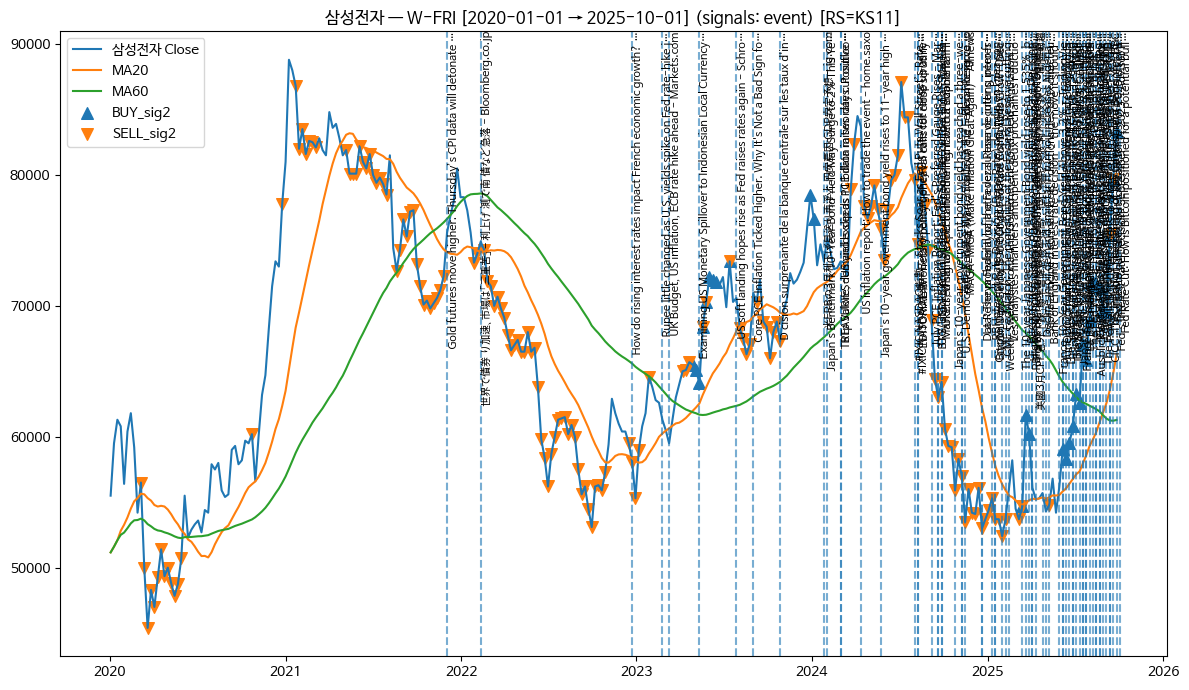

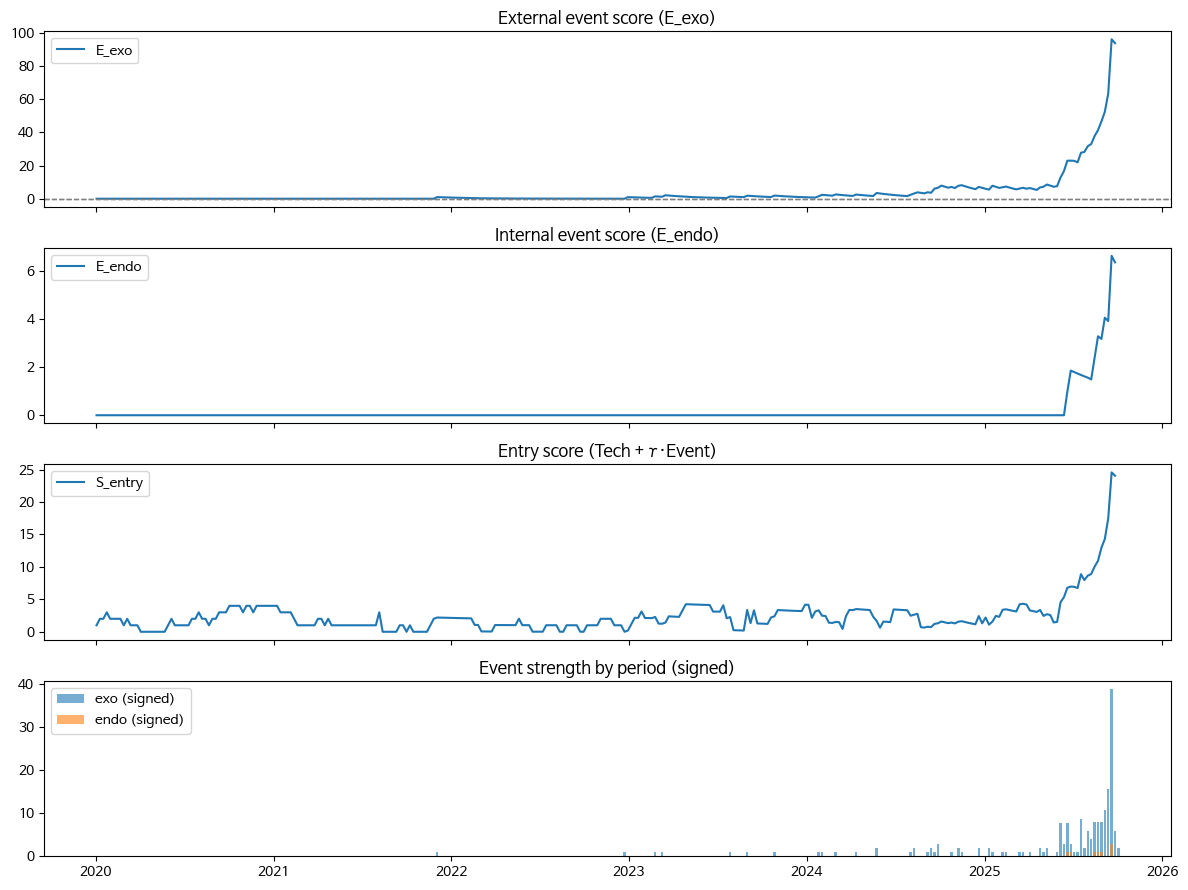

{'root_dir': './verif_exports/005930_W-FRI_20251019-092600',
 'mix_raw_core': './verif_exports/005930_W-FRI_20251019-092600/mix_raw_core.csv',
 'mix_raw_full': './verif_exports/005930_W-FRI_20251019-092600/mix_raw_full.csv',
 'adapter_summary': './verif_exports/005930_W-FRI_20251019-092600/adapter_summary.csv',
 'mix_after_adapter_core': './verif_exports/005930_W-FRI_20251019-092600/mix_after_adapter_core.csv',
 'mix_after_sizing_core': './verif_exports/005930_W-FRI_20251019-092600/mix_after_sizing_core.csv',
 'backtest_perf': './verif_exports/005930_W-FRI_20251019-092600/backtest_perf_summary.csv',
 'bt_detail_files': ['./verif_exports/005930_W-FRI_20251019-092600/bt_result_table.csv'],
 'events_used': './verif_exports/005930_W-FRI_20251019-092600/events_used_window.csv',
 'readme': './verif_exports/005930_W-FRI_20251019-092600/_README_verification.txt'}

In [44]:
# 0) 파라미터 (예시)
params = EventRuleParams(theta_on=0.12, theta_off=-0.12, alpha=0.5, beta=0.5, gamma=0.4, tau_buy=4)

# 사이징(없으면 export_verification_bundle가 기본 생성)
size_params = SizingParams(
    w_t=0.6, w_e=0.4, lambda_evt=1.2,
    atr_floor=0.012, risk_scale=0.6, w_max=1.0,
    use_kelly=True, kelly_frac=0.25, kelly_lookback=20, kelly_mix=0.3,
    riskon_penalty=0.6
)

# 1) 번들 생성
paths = export_verification_bundle(
    symbol="005930",             # 삼성전자
    events_df=events,            # 이미 로드한 이벤트 DF (없으면 None)
    params=params,
    basis="W-FRI",
    start_date="2020-01-01",
    end_date="2025-10-01",
    warmup_days=120,
    # 어댑터(이미 스코어에 소스가중 반영되어 있다면 source_power=0.0 권장)
    adapter_mode="gamma_only",
    cap_per_period=2, roll_periods=104, min_cov=0.2,
    alpha=0.6, beta=0.6,
    source_weight=None, source_power=0.0,
    # 사이징/백테스트
    size_params=size_params,
    use_event_signals=True,
    fee_bps=10, slippage_bps=5,
    exec_at="open",
    use_position_sizing=True,
    out_dir="./verif_exports"
)

paths
